# Data Analytics - Datathon Passos Mágicos

**Associação Passos Mágicos** · Pós Tech · Fase 5

---
# Preparação do ambiente

In [1]:
import re
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

# paleta usada no notebook inteiro
COR = {
    "principal": "#2b6cb0",
    "apoio": "#63b3ed",
    "alerta": "#c53030",
    "atencao": "#dd6b20",
    "ok": "#2f855a",
    "neutro": "#718096",
}
PALETA_PEDRA = {
    "Quartzo": "#a0aec0",
    "Ágata": "#68a4c4",
    "Ametista": "#805ad5",
    "Topázio": "#d69e2e",
}
SEMENTE = 42

In [2]:
# o notebook fica na raiz do projeto e os CSVs em Arquivos_Base/
PASTA_BASE = Path.cwd() / "Arquivos_Base"

ARQUIVOS_ANO = {
    2022: "BASE DE DADOS PEDE 2022.csv",
    2023: "BASE DE DADOS PEDE 2023.csv",
    2024: "BASE DE DADOS PEDE 2024.csv",
}

ANOS = [2022, 2023, 2024]
INDICADORES = ["IAA", "IEG", "IPS", "IPP", "IDA", "IPV", "IAN"]
ORDEM_PEDRA = ["Quartzo", "Ágata", "Ametista", "Topázio"]

NOME_INDICADOR = {
    "IAA": "Autoavaliação",
    "IEG": "Engajamento",
    "IPS": "Psicossocial",
    "IPP": "Psicopedagógico",
    "IDA": "Aprendizagem",
    "IPV": "Ponto de Virada",
    "IAN": "Adequação ao Nível",
}

print("Pasta de dados:", PASTA_BASE)
for arquivo in sorted(PASTA_BASE.glob("*.csv")):
    print(f"  {arquivo.name:38s} {arquivo.stat().st_size/1024:7.0f} KB")

Pasta de dados: c:\Users\USUARIO\Documents\GitHub\datathon_2026\Arquivos_Base
  BASE DE DADOS PEDE 2020_2022.csv           853 KB
  BASE DE DADOS PEDE 2022.csv                378 KB
  BASE DE DADOS PEDE 2023.csv                237 KB
  BASE DE DADOS PEDE 2024.csv                342 KB


# 1. Entendimento dos dados e arquivos fonte

São três CSVs um por ano - 2022, 2023 e 2024

In [3]:
def ler_csv(nome_arquivo: str) -> pd.DataFrame:
    caminho = PASTA_BASE / nome_arquivo
    df = pd.read_csv(caminho, sep=";", encoding="utf-8-sig", dtype=str)
    return df.dropna(how="all").reset_index(drop=True)

brutos = {ano: ler_csv(arq) for ano, arq in ARQUIVOS_ANO.items()}

resumo = pd.DataFrame(
    [{"fonte": f"PEDE {ano}", "linhas": df.shape[0], "colunas": df.shape[1]}
     for ano, df in brutos.items()]
)
resumo

,fonte,linhas,colunas
0,PEDE 2022,860,42
1,PEDE 2023,1014,48
2,PEDE 2024,1156,50


In [4]:
for ano, df in brutos.items():
    print(f"PEDE {ano} ({df.shape[1]} colunas)")
    print(list(df.columns))
    print()

PEDE 2022 (42 colunas)
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

PEDE 2023 (48 colunas)
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasagem', '

Identificação dos padrões de preenchimento entre os arquivos

In [5]:
#Comparativo entre os padrões de preenchimento entre os dados para cada conceito
def comparar_nomes(conceitos: dict[str, list[str]]) -> pd.DataFrame:
    linhas = []
    for conceito, apelidos in conceitos.items():
        linha = {"conceito": conceito}
        for ano, df in brutos.items():
            achados = [c for c in df.columns if c in apelidos]
            linha[ano] = achados[0] if achados else "AUSENTE"
        linhas.append(linha)
    return pd.DataFrame(linhas).set_index("conceito")


comparar_nomes({
    "Identificador":   ["RA"],
    "Nome":            ["Nome", "Nome Anonimizado"],
    "INDE":            ["INDE 22", "INDE 2023", "INDE 2024"],
    "Pedra":           ["Pedra 22", "Pedra 2023", "Pedra 2024"],
    "Idade":           ["Idade 22", "Idade"],
    "Nascimento":      ["Ano nasc", "Data de Nasc"],
    "Nota Matemática": ["Matem", "Mat"],
    "Nota Português":  ["Portug", "Por"],
    "Nota Inglês":     ["Inglês", "Ing"],
    "Fase ideal":      ["Fase ideal", "Fase Ideal"],
    "Defasagem":       ["Defas", "Defasagem"],
    "Psicopedagógico": ["IPP"],
    "Escola":          ["Escola"],
})

,2022,2023,2024
conceito,,,
Identificador,RA,RA,RA
Nome,Nome,Nome Anonimizado,Nome Anonimizado
INDE,INDE 22,INDE 2023,INDE 2024
Pedra,Pedra 22,Pedra 2023,Pedra 2024
Idade,Idade 22,Idade,Idade
Nascimento,Ano nasc,Data de Nasc,Data de Nasc
Nota Matemática,Matem,Mat,Mat
Nota Português,Portug,Por,Por
Nota Inglês,Inglês,Ing,Ing


Observações encontradas:

- **IPP** não existe em 2022
- **Escola** só aparece em 2024, não dá para usar em série histórica
- os arquivos de 2023 e 2024 carregam colunas de anos anteriores (`Pedra 20`, `Pedra 21`,
  `INDE 22`, `INDE 23`). São ecos do histórico do aluno, não o valor daquele ano — o mapa
  de colunas da Parte 2 precisa ignorá-las de propósito

## Conversão numérica

Tudo é lido como texto, então a primeira função do pipeline é a que transforma texto em
número respeitando o padrão brasileiro.

In [6]:
def para_numero(serie: pd.Series) -> pd.Series:

    if pd.api.types.is_numeric_dtype(serie):
        return serie.astype("float64")

    texto = serie.astype("string").str.strip()
    texto = texto.str.replace(r"^#.*!$", "", regex=True)

    eh_percentual = texto.str.endswith("%", na=False)
    texto = texto.str.rstrip("%")

    # o ponto só é milhar quando há vírgula na mesma célula
    tem_virgula = texto.str.contains(",", na=False)
    texto = texto.mask(tem_virgula, texto.str.replace(".", "", regex=False))
    texto = texto.str.replace(",", ".", regex=False)

    numero = pd.to_numeric(texto, errors="coerce")
    return numero.mask(eh_percentual, numero / 100)

## Identificação de linhas e colunas nulas

In [7]:
for ano, df in brutos.items():
    vazias = [c for c in df.columns if df[c].notna().sum() == 0]
    parciais = {c: f"{df[c].notna().mean():.0%}"
                for c in df.columns if 0 < df[c].notna().mean() < 0.95}
    print(f"PEDE {ano}")
    print(f"  linhas totalmente vazias : {int(df.isna().all(axis=1).sum())}")
    print(f"  colunas totalmente vazias ({len(vazias)}): {vazias}")
    print(f"  colunas preenchidas em parte: {parciais}")
    print()

PEDE 2022
  linhas totalmente vazias : 0
  colunas totalmente vazias (0): []
  colunas preenchidas em parte: {'Pedra 20': '38%', 'Pedra 21': '54%', 'Avaliador3': '62%', 'Avaliador4': '36%', 'Rec Av4': '34%', 'Inglês': '33%'}

PEDE 2023
  linhas totalmente vazias : 0
  colunas totalmente vazias (16): ['Pedra 23', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Av3', 'Rec Av4', 'Rec Psicologia', 'Indicado', 'Atingiu PV', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'Destaque IPV.1']
  colunas preenchidas em parte: {'INDE 2023': '92%', 'Pedra 2023': '92%', 'Pedra 20': '24%', 'Pedra 21': '33%', 'Pedra 22': '59%', 'INDE 22': '59%', 'Nº Av': '93%', 'Avaliador1': '93%', 'Avaliador2': '93%', 'Avaliador3': '70%', 'Avaliador4': '33%', 'IAA': '94%', 'IEG': '93%', 'IPS': '93%', 'IPP': '93%', 'IDA': '92%', 'Mat': '92%', 'Por': '92%', 'Ing': '33%', 'IPV': '93%'}

PEDE 2024
  linhas totalmente vazias : 0
  colunas totalmente vazias (11): ['Cg', 'Cf', 'Ct', 'Rec Av1', 'Rec Av2', 'Rec Psicol

> ### Conclusão: o Ponto de Virada não pode ser o alvo do modelo
>
> Atingiu PV, Indicado, Rec Psicologia e os campos Destaque estão **100% vazios
> em 2023 e 2024**. Só existem preenchidos em 2022.
>
> Isso elimina "atingir o Ponto de Virada" como variável-resposta: não haveria rótulo nos
> anos recentes para treinar nem para validar. O alvo terá que ser construído a partir da
> **defasagem**, que está completa nos três anos


In [8]:
# preenchimento dos indicadores
cobertura = pd.DataFrame({
    ano: {
        col: brutos[ano][col].notna().mean() * 100 if col in brutos[ano].columns else np.nan
        for col in INDICADORES
    }
    for ano in ANOS
})
cobertura.loc["INDE"] = [
    brutos[a][c].notna().mean() * 100
    for a, c in zip(ANOS, ["INDE 22", "INDE 2023", "INDE 2024"])
]
cobertura.round(1)

,2022,2023,2024
IAA,100.000,93.800,91.200
IEG,100.000,92.500,100.000
IPS,100.000,93.200,91.200
IPP,NaN,92.500,91.200
IDA,100.000,92.400,91.300
IPV,100.000,92.500,91.200
IAN,100.000,100.000,100.000
INDE,100.000,91.800,94.500


`IAN` é o único indicador com 100% de cobertura nos três anos - mais um argumento a
favor de ancorar o alvo do modelo na defasagem. Os demais faltam para 7% a 9% dos alunos
de 2023/2024, tipicamente quem entrou no meio do ciclo.

## Padrões de preenchimento entre colunas

In [9]:
# Em 2023 parte das idades foi gravada como data
idade_2023 = brutos[2023]["Idade"]
parece_data = idade_2023.str.contains("1900", na=False)

print(f"Valores de 'Idade' que viraram data em 2023: {parece_data.sum()} de {len(idade_2023)}")
print("Exemplos:", idade_2023[parece_data].unique()[:6].tolist())
print("Normais :", idade_2023[~parece_data].dropna().unique()[:6].tolist())

Valores de 'Idade' que viraram data em 2023: 399 de 1014
Exemplos: ['1900-01-08 00:00:00', '1900-01-07 00:00:00', '1900-01-11 00:00:00', '1900-01-09 00:00:00', '1900-01-10 00:00:00', '1900-01-14 00:00:00']
Normais : ['8', '9', '7', '10', '12', '11']


In [10]:
# A coluna Fase muda de significado a cada ano
for ano in ANOS:
    valores = sorted(brutos[ano]["Fase"].dropna().unique())
    print(f"{ano} ({len(valores):2d} valores distintos): {valores[:14]}")

2022 ( 8 valores distintos): ['0', '1', '2', '3', '4', '5', '6', '7']
2023 ( 9 valores distintos): ['ALFA', 'FASE 1', 'FASE 2', 'FASE 3', 'FASE 4', 'FASE 5', 'FASE 6', 'FASE 7', 'FASE 8']
2024 (72 valores distintos): ['1A', '1B', '1C', '1D', '1E', '1G', '1H', '1J', '1K', '1L', '1M', '1N', '1P', '1R']


In [11]:
# Categorias escritas de formas diferentes
for coluna in ["Gênero", "Instituição de ensino"]:
    print(f"{coluna}")
    for ano in ANOS:
        print(f"  {ano}: {sorted(brutos[ano][coluna].dropna().unique())}")
    print()

print("Pedra")
for ano, col in zip(ANOS, ["Pedra 22", "Pedra 2023", "Pedra 2024"]):
    print(f"  {ano}: {sorted(brutos[ano][col].dropna().unique())}")

Gênero
  2022: ['Menina', 'Menino']
  2023: ['Feminino', 'Masculino']
  2024: ['Feminino', 'Masculino']

Instituição de ensino
  2022: ['Escola JP II', 'Escola Pública', 'Rede Decisão']
  2023: ['Concluiu o 3º EM', 'Nenhuma das opções acima', 'Privada', 'Privada *Parcerias com Bolsa 100%', 'Privada - Pagamento por *Empresa Parceira', 'Privada - Programa de Apadrinhamento', 'Privada - Programa de apadrinhamento', 'Pública']
  2024: ['Bolsista Universitário *Formado (a)', 'Concluiu o 3º EM', 'Privada', 'Privada *Parcerias com Bolsa 100%', 'Privada - Pagamento por *Empresa Parceira', 'Privada - Programa de Apadrinhamento', 'Privada - Programa de apadrinhamento', 'Pública']

Pedra
  2022: ['Ametista', 'Quartzo', 'Topázio', 'Ágata']
  2023: ['Agata', 'Ametista', 'Quartzo', 'Topázio']
  2024: ['Agata', 'Ametista', 'INCLUIR', 'Quartzo', 'Topázio']


`Ágata` perde o acento a partir de 2023 e aparece um valor de controle `INCLUIR` em
2024. Sem tratamento, `Ágata` e `Agata` viram duas categorias

In [12]:
# Todo número chega como texto, com vírgula decimal
amostra = brutos[2023]["IPS"]
print("Exemplos de IPS em 2023:", amostra.dropna().unique()[:6].tolist())
print("Depois da conversão    :", para_numero(amostra).dropna().unique()[:6].tolist())
print()

# colunas duplicadas na planilha ganham sufixo .1 na leitura
duplicadas = {ano: [c for c in df.columns if c.endswith(".1")] for ano, df in brutos.items()}
print("Colunas duplicadas na origem:", {a: v for a, v in duplicadas.items() if v})

Exemplos de IPS em 2023: ['8,13', '8,14', '3,14', '7,52', '8,76', '3,76']
Depois da conversão    : [8.13, 8.14, 3.14, 7.52, 8.76, 3.76]

Colunas duplicadas na origem: {2023: ['Destaque IPV.1'], 2024: ['Ativo/ Inativo.1']}


---
# 2. Consolidação dos Dados

## Funções de padronização

In [13]:
def sem_acento(texto: str) -> str:
    return "".join(
        c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c)
    )

# Maiúsculas, sem acento e sem espaços nas pontas
def normalizar_texto(serie: pd.Series) -> pd.Series:
    return (
        serie.astype("string").str.strip().str.upper()
        .map(sem_acento, na_action="ignore")
    )

# 'ALFA' -> 0 | 'FASE 3' -> 3 | '3B' -> 3 | '7' -> 7
def fase_para_numero(serie: pd.Series) -> pd.Series:
    texto = normalizar_texto(serie)
    numero = pd.Series(np.nan, index=serie.index, dtype="float64")
    numero = numero.mask(texto.str.startswith("ALFA", na=False), 0.0)
    return numero.fillna(pd.to_numeric(texto.str.extract(r"(\d+)")[0], errors="coerce"))

# 'ALFA (1º e 2º ano)' -> 0 | 'Fase 5 (1º EM)' -> 5
def fase_ideal_para_numero(serie: pd.Series) -> pd.Series:
    texto = normalizar_texto(serie)
    numero = pd.Series(np.nan, index=serie.index, dtype="float64")
    numero = numero.mask(texto.str.startswith("ALFA", na=False), 0.0)
    extraido = texto.str.extract(r"FASE\s*(\d+)")[0]
    return numero.fillna(pd.to_numeric(extraido, errors="coerce"))

def para_booleano(serie: pd.Series) -> pd.Series:
    return normalizar_texto(serie).map({"SIM": True, "NAO": False}).astype("boolean")


MAPA_GENERO = {"MENINA": "F", "FEMININO": "F", "MENINO": "M", "MASCULINO": "M"}

MAPA_INSTITUICAO = {
    "ESCOLA PUBLICA": "Pública",
    "PUBLICA": "Pública",
    "PRIVADA": "Privada",
    "REDE DECISAO": "Privada - Parceira",
    "ESCOLA JP II": "Privada - Parceira",
    "PRIVADA - PROGRAMA DE APADRINHAMENTO": "Privada - Apadrinhamento",
    "PRIVADA *PARCERIAS COM BOLSA 100%": "Privada - Bolsa 100%",
    "PRIVADA - PAGAMENTO POR *EMPRESA PARCEIRA": "Privada - Empresa parceira",
    "CONCLUIU O 3º EM": "Concluiu o 3º EM",
    "CONCLUIU O 3O EM": "Concluiu o 3º EM",
    "NENHUMA DAS OPCOES ACIMA": "Nenhuma",
}

MAPA_PEDRA = {
    "QUARTZO": "Quartzo", "AGATA": "Ágata",
    "AMETISTA": "Ametista", "TOPAZIO": "Topázio",
}

# Resolve 'Agata' sem acento e descarta o valor de controle 'INCLUIR'
def padronizar_pedra(serie: pd.Series) -> pd.Categorical:
    return pd.Categorical(
        normalizar_texto(serie).map(MAPA_PEDRA),
        categories=ORDEM_PEDRA, ordered=True,
    )

# Idades gravadas como '1900-01-08' voltam a ser 8 (o dia é a idade)
def corrigir_idade(serie: pd.Series) -> pd.Series:
    texto = serie.astype("string").str.strip()
    numero = pd.to_numeric(texto, errors="coerce")

    eh_data_1900 = texto.str.match(r"1900-\d{2}-\d{2}").fillna(False)
    dia = pd.to_numeric(texto.str.extract(r"^1900-\d{2}-(\d{2})")[0], errors="coerce")
    return numero.mask(eh_data_1900, dia).astype("float64")

# Só o ANO. A coluna mistura '6/17/2015' (mês/dia/ano digitado à mão) com '2015-12-03' (formatado pelo Excel) — o ano é a única parte confiável em ambos
def extrair_ano_nascimento(serie: pd.Series) -> pd.Series:
    texto = serie.astype("string").str.strip()
    ano_iso = texto.str.extract(r"^(\d{4})-")[0]
    ano_final = texto.str.extract(r"(\d{4})\s*$")[0]
    return pd.to_numeric(ano_iso.fillna(ano_final), errors="coerce").astype("float64")

## Padronização no nome das colunas

Cada ano declara de onde vem cada conceito. Duas armadilhas ficam explícitas aqui:

- conceitos que não existem naquele ano (`IPP` em 2022) simplesmente não entram no mapa e
  viram nulo;
- as colunas de **eco histórico** (`Pedra 20`, `Pedra 21`, `Pedra 22`, `Pedra 23`,
  `INDE 22`, `INDE 23`) ficam de fora de propósito. No arquivo de 2023, por exemplo,
  existem `INDE 22` e `INDE 2023` lado a lado; usar a primeira por engano faria o painel
  registrar o desempenho do ano anterior como se fosse do ano corrente.

In [14]:
MAPA_COLUNAS = {
    2022: {
        "id_aluno": "RA", "nome": "Nome", "fase_bruta": "Fase", "turma": "Turma",
        "ano_nascimento_bruto": "Ano nasc", "idade": "Idade 22", "genero": "Gênero",
        "ano_ingresso": "Ano ingresso", "instituicao": "Instituição de ensino",
        "inde": "INDE 22", "pedra": "Pedra 22",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Matem", "nota_por": "Portug", "nota_ing": "Inglês",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase ideal", "defasagem_original": "Defas",
    },
    2023: {
        "id_aluno": "RA", "nome": "Nome Anonimizado", "fase_bruta": "Fase",
        "turma": "Turma", "data_nascimento": "Data de Nasc", "idade": "Idade",
        "genero": "Gênero", "ano_ingresso": "Ano ingresso",
        "instituicao": "Instituição de ensino",
        "inde": "INDE 2023", "pedra": "Pedra 2023",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IPP": "IPP", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Mat", "nota_por": "Por", "nota_ing": "Ing",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase Ideal", "defasagem_original": "Defasagem",
    },
    2024: {
        "id_aluno": "RA", "nome": "Nome Anonimizado", "fase_bruta": "Fase",
        "turma": "Turma", "data_nascimento": "Data de Nasc", "idade": "Idade",
        "genero": "Gênero", "ano_ingresso": "Ano ingresso",
        "instituicao": "Instituição de ensino", "escola": "Escola",
        "inde": "INDE 2024", "pedra": "Pedra 2024",
        "rank_geral": "Cg", "rank_fase": "Cf", "rank_turma": "Ct",
        "qtd_avaliadores": "Nº Av",
        "IAA": "IAA", "IEG": "IEG", "IPS": "IPS", "IPP": "IPP", "IDA": "IDA",
        "IPV": "IPV", "IAN": "IAN",
        "nota_mat": "Mat", "nota_por": "Por", "nota_ing": "Ing",
        "atingiu_pv": "Atingiu PV", "indicado_bolsa": "Indicado",
        "fase_ideal_bruta": "Fase Ideal", "defasagem_original": "Defasagem",
    },
}

COLUNAS_NUMERICAS = [
    "inde", "rank_geral", "rank_fase", "rank_turma", "qtd_avaliadores",
    "nota_mat", "nota_por", "nota_ing", "ano_ingresso", *INDICADORES,
]

ROTULO_DEFASAGEM = ["Severa (3+)", "Alta (2)", "Moderada (1)", "Adequado", "Adiantado"]

In [15]:
def padronizar_ano(ano: int) -> pd.DataFrame:
    bruto = brutos[ano]
    mapa = MAPA_COLUNAS[ano]

    df = pd.DataFrame(index=bruto.index)
    df["ano"] = ano
    for canonico, original in mapa.items():
        df[canonico] = bruto[original] if original in bruto.columns else pd.NA

    # garante que todo indicador exista, mesmo ausente naquele ano
    for indicador in INDICADORES:
        if indicador not in df.columns:
            df[indicador] = np.nan

    df["id_aluno"] = df["id_aluno"].astype("string").str.strip()
    df["nome"] = df["nome"].astype("string").str.strip()
    df["turma"] = df["turma"].astype("string").str.strip()

    for coluna in COLUNAS_NUMERICAS:
        df[coluna] = para_numero(df[coluna])

    df["fase"] = fase_para_numero(df["fase_bruta"])
    df["fase_ideal"] = fase_ideal_para_numero(df["fase_ideal_bruta"])
    df["defasagem_original"] = para_numero(df["defasagem_original"])
    df["pedra"] = padronizar_pedra(df["pedra"])
    df["genero"] = normalizar_texto(df["genero"]).map(MAPA_GENERO).astype("string")

    instituicao = normalizar_texto(df["instituicao"])
    df["instituicao"] = (
        instituicao.map(MAPA_INSTITUICAO)
        .fillna(df["instituicao"].astype("string").str.strip())
        .astype("string")
    )

    df["idade"] = corrigir_idade(df["idade"])
    if "data_nascimento" in df.columns:
        df["ano_nascimento"] = extrair_ano_nascimento(df["data_nascimento"])
    else:
        df["ano_nascimento"] = para_numero(df["ano_nascimento_bruto"])
    df["idade"] = df["idade"].fillna(ano - df["ano_nascimento"])

    for coluna in ("atingiu_pv", "indicado_bolsa"):
        df[coluna] = para_booleano(df[coluna])

    # derivadas
    df["defasagem"] = df["fase"] - df["fase_ideal"]
    df["defasado"] = df["defasagem"] < 0
    df["nivel_defasagem"] = pd.Categorical(
        pd.cut(df["defasagem"], bins=[-np.inf, -2.5, -1.5, -0.5, 0.5, np.inf],
               labels=ROTULO_DEFASAGEM),
        categories=ROTULO_DEFASAGEM, ordered=True,
    )

    return df.drop(columns=[
        "fase_bruta", "fase_ideal_bruta", "data_nascimento", "ano_nascimento_bruto",
    ], errors="ignore")


ORDEM_FINAL = [
    "id_aluno", "ano", "nome", "genero", "idade", "ano_nascimento",
    "ano_ingresso", "anos_na_pm", "instituicao", "escola", "turma",
    "fase", "fase_ideal", "defasagem", "defasado", "nivel_defasagem",
    "inde", "pedra", *INDICADORES,
    "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores",
    "rank_geral", "rank_fase", "rank_turma",
    "atingiu_pv", "indicado_bolsa", "defasagem_original",
]


def construir_painel() -> pd.DataFrame:
    painel = pd.concat([padronizar_ano(a) for a in ANOS], ignore_index=True, sort=False)

    # Ano ingresso diverge entre anos para o mesmo aluno, adotado o menor
    painel["ano_ingresso_declarado"] = painel["ano_ingresso"]
    painel["ano_ingresso"] = painel.groupby("id_aluno")["ano_ingresso"].transform("min")
    painel["ingresso_inconsistente"] = (
        painel.groupby("id_aluno")["ano_ingresso_declarado"].transform("nunique") > 1
    )
    painel["anos_na_pm"] = painel["ano"] - painel["ano_ingresso"]
    painel["n_anos_observados"] = painel.groupby("id_aluno")["ano"].transform("size")

    colunas = [c for c in ORDEM_FINAL if c in painel.columns]
    restantes = [c for c in painel.columns if c not in colunas]
    return (
        painel[colunas + restantes]
        .sort_values(["id_aluno", "ano"])
        .reset_index(drop=True)
    )


painel = construir_painel()

## Checagem do df consolidado:

In [16]:
print("Painel:", painel.shape)
painel.head(6)

Painel: (3030, 38)


,id_aluno,ano,nome,genero,idade,ano_nascimento,ano_ingresso,anos_na_pm,instituicao,escola,turma,fase,fase_ideal,defasagem,defasado,nivel_defasagem,inde,pedra,IAA,IEG,IPS,IPP,IDA,IPV,IAN,nota_mat,nota_por,nota_ing,qtd_avaliadores,rank_geral,rank_fase,rank_turma,atingiu_pv,indicado_bolsa,defasagem_original,ano_ingresso_declarado,ingresso_inconsistente,n_anos_observados
0,RA-1,2022,Aluno-1,F,19.000,"2,003.000",2016,6,Pública,NaN,A,7.000,8.000,-1.000,True,Moderada (1),5.783,Quartzo,8.300,4.100,5.600,<NA>,4.000,7.278,5.000,2.700,3.500,6.000,4.000,753,18,10,False,True,-1,2016,True,3
1,RA-1,2023,Aluno-1,F,20.000,"2,003.000",2016,7,Privada - Bolsa 100%,NaN,8E,8.000,8.000,0.000,False,Adequado,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,10.000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,2016,True,3
2,RA-1,2024,Aluno-1,F,21.000,"2,003.000",2016,8,Privada - Bolsa 100%,Universidade Santo Amaro (UNISA),8E,8.000,8.000,0.000,False,Adequado,<NA>,NaN,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,10.000,<NA>,<NA>,<NA>,0.000,<NA>,<NA>,<NA>,<NA>,<NA>,0,2021,True,3
3,RA-10,2022,Aluno-10,F,18.000,"2,004.000",2021,1,Pública,NaN,A,7.000,8.000,-1.000,True,Moderada (1),5.784,Quartzo,8.300,5.200,5.000,<NA>,4.100,7.056,5.000,3.300,2.600,6.400,4.000,752,17,9,False,False,-1,2021,False,1
4,RA-100,2022,Aluno-100,F,13.000,"2,009.000",2019,3,Privada - Parceira,NaN,A,4.000,3.000,1.000,False,Adiantado,7.618,Ametista,8.800,7.800,5.000,<NA>,7.600,7.250,10.000,7.000,7.800,8.100,4.000,268,22,7,False,False,1,2019,False,1
5,RA-1000,2023,Aluno-1000,F,8.000,"2,015.000",2023,0,Pública,NaN,ALFA U - G2/G3,0.000,0.000,0.000,False,Adequado,7.916,Ametista,8.500,9.400,3.770,6.250,7.000,8.920,10.000,7.000,7.000,<NA>,2.000,<NA>,<NA>,<NA>,<NA>,<NA>,0,2023,False,2


In [17]:
painel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id_aluno                3030 non-null   string  
 1   ano                     3030 non-null   int64   
 2   nome                    3030 non-null   string  
 3   genero                  3030 non-null   string  
 4   idade                   3030 non-null   float64 
 5   ano_nascimento          3030 non-null   Float64 
 6   ano_ingresso            3030 non-null   Int64   
 7   anos_na_pm              3030 non-null   Int64   
 8   instituicao             3029 non-null   string  
 9   escola                  1155 non-null   object  
 10  turma                   3030 non-null   string  
 11  fase                    3030 non-null   float64 
 12  fase_ideal              3030 non-null   float64 
 13  defasagem               3030 non-null   float64 
 14  defasado                

## 2.3 Validações

Seis checagens antes de confiar no painel.

In [18]:
# V1 — a chave aluno × ano é única?
chaves_repetidas = painel.duplicated(["id_aluno", "ano"]).sum()
print(f"V1  duplicidades aluno×ano: {chaves_repetidas}")

# V2 — a defasagem recalculada bate com a que veio na planilha?
comparavel = painel.dropna(subset=["defasagem", "defasagem_original"])
iguais = (comparavel["defasagem"] == comparavel["defasagem_original"])
print(f"V2  defasagem recalculada == original: {iguais.mean():.2%} de {len(comparavel)} linhas")
display(comparavel.loc[~iguais, ["id_aluno", "ano", "fase", "fase_ideal",
                                 "defasagem", "defasagem_original"]])

V1  duplicidades aluno×ano: 0
V2  defasagem recalculada == original: 99.93% de 3030 linhas


,id_aluno,ano,fase,fase_ideal,defasagem,defasagem_original
831,RA-1516,2024,3.000,3.000,0.000,3
834,RA-1519,2024,3.000,3.000,0.000,3


In [19]:
# V3 — a Pedra corresponde às faixas de INDE do dicionário de dados?
FAIXAS_DICIONARIO = {
    "Quartzo": (2.405, 5.506), "Ágata": (5.506, 6.868),
    "Ametista": (6.868, 8.230), "Topázio": (8.230, 9.294),
}

def classificar(valor, faixas):
    if pd.isna(valor):
        return None
    for pedra, (minimo, maximo) in faixas.items():
        if minimo <= valor <= maximo:
            return pedra
    return "fora das faixas"

conferencia = painel.dropna(subset=["inde", "pedra"]).copy()
conferencia["pelo_dicionario"] = conferencia["inde"].map(
    lambda v: classificar(v, FAIXAS_DICIONARIO)
)
print("V3  Pedra informada × faixa do dicionário:")
display(pd.crosstab(conferencia["pedra"], conferencia["pelo_dicionario"]))

print("Limites de INDE observados em cada pedra:")
display(
    conferencia.groupby(["ano", "pedra"], observed=True)["inde"]
    .agg(["min", "max", "size"]).round(3)
)

V3  Pedra informada × faixa do dicionário:


pelo_dicionario,Ametista,Quartzo,Topázio,fora das faixas,Ágata
pedra,,,,,
Quartzo,0,149,0,0,167
Ágata,128,0,0,0,593
Ametista,1120,0,0,0,0
Topázio,219,0,457,12,0


Limites de INDE observados em cada pedra:


min   max  size
ano  pedra                     
2022 Quartzo  3.032 5.989   132
     Ágata    6.011 7.028   250
     Ametista 7.035 8.058   348
     Topázio  8.060 9.442   130
2023 Quartzo  3.746 5.996    72
     Ágata    6.009 6.994   246
     Ametista 7.000 7.997   381
     Topázio  8.003 9.371   232
2024 Quartzo  3.789 5.984   112
     Ágata    6.015 7.000   225
     Ametista 7.003 7.994   391
     Topázio  8.003 9.531   326

> ### Conclusão 2 — o dicionário de dados está desatualizado
>
> A Pedra informada **não** segue as faixas do dicionário. Os cortes efetivos em
> 2022–2024 são redondos: Quartzo `< 6`, Ágata `[6, 7)`, Ametista `[7, 8)`,
> Topázio `>= 8`. O dicionário descreve o ciclo antigo (2020–2022).
>
> Nunca reclassificar alunos pelas faixas do dicionário — e vale registrar isso como
> recomendação de governança de dados para a Passos Mágicos.

In [20]:
# V4 — o ano de ingresso é consistente para o mesmo aluno?
inconsistentes = painel.drop_duplicates("id_aluno")["ingresso_inconsistente"].sum()
total_alunos = painel["id_aluno"].nunique()
print(f"V4  alunos com ano de ingresso divergente: {inconsistentes} de {total_alunos} "
      f"({inconsistentes/total_alunos:.1%})")
display(
    painel[painel["ingresso_inconsistente"]]
    .head(6)[["id_aluno", "ano", "ano_ingresso_declarado", "ano_ingresso", "anos_na_pm"]]
)

V4  alunos com ano de ingresso divergente: 201 de 1661 (12.1%)


,id_aluno,ano,ano_ingresso_declarado,ano_ingresso,anos_na_pm
0,RA-1,2022,2016,2016,6
1,RA-1,2023,2016,2016,7
2,RA-1,2024,2021,2016,8
61,RA-103,2022,2020,2020,2
62,RA-103,2023,2020,2020,3
63,RA-103,2024,2021,2020,4


A aba de 2024 reescreveu boa parte dos ingressos antigos para 2021. Usar o valor da
linha como está faria o tempo de casa de um veterano **encolher** de 7 para 3 anos, o que
quebraria qualquer variável de senioridade. O painel adota o menor ano declarado.

In [21]:
# V5 — cobertura final por ano
print("V5  registros e preenchimento por ano")
display(painel.groupby("ano").size().rename("registros").to_frame().T)
display(
    painel.groupby("ano")[["inde", *INDICADORES]]
    .apply(lambda d: d.notna().mean() * 100).round(1)
)

print("Quantos anos cada aluno aparece:")
print(painel.drop_duplicates("id_aluno")["n_anos_observados"].value_counts().sort_index())

V5  registros e preenchimento por ano


ano,2022,2023,2024
registros,860,1014,1156


,inde,IAA,IEG,IPS,IPP,IDA,IPV,IAN
ano,,,,,,,,
2022,100.000,100.000,100.000,100.000,0.000,100.000,100.000,100.000
2023,91.800,93.800,92.500,93.200,92.500,92.400,92.500,100.000
2024,91.200,91.200,100.000,91.200,91.200,91.300,91.200,100.000


Quantos anos cada aluno aparece:
n_anos_observados
1    760
2    433
3    468
Name: count, dtype: int64


In [22]:
# V6 — o RA aponta para o mesmo aluno nos três arquivos?
# os arquivos de 2023 e 2024 guardam o INDE de anos anteriores; esses valores têm que
# ser idênticos ao que o arquivo daquele ano registra para o mesmo RA
def conferir_eco(ano_fonte: int, coluna_fonte: str,
                 ano_eco: int, coluna_eco: str) -> dict:
    fonte = pd.DataFrame({
        "RA": brutos[ano_fonte]["RA"],
        "valor_fonte": para_numero(brutos[ano_fonte][coluna_fonte]),
    })
    eco = pd.DataFrame({
        "RA": brutos[ano_eco]["RA"],
        "valor_eco": para_numero(brutos[ano_eco][coluna_eco]),
    })
    juntos = fonte.merge(eco, on="RA", how="inner").dropna()
    confere = np.isclose(juntos["valor_fonte"], juntos["valor_eco"], atol=0.001)
    return {
        "comparação": f"INDE {ano_fonte} no arquivo de {ano_eco}",
        "alunos": len(juntos),
        "confere": int(confere.sum()),
        "%": round(confere.mean() * 100, 1),
    }


print("V6  consistência do RA entre arquivos")
display(pd.DataFrame([
    conferir_eco(2022, "INDE 22", 2023, "INDE 22"),
    conferir_eco(2022, "INDE 22", 2024, "INDE 22"),
    conferir_eco(2023, "INDE 2023", 2024, "INDE 23"),
]))

V6  consistência do RA entre arquivos


,comparação,alunos,confere,%
0,INDE 2022 no arquivo de 2023,600,600,100.000
1,INDE 2022 no arquivo de 2024,472,472,100.000
2,INDE 2023 no arquivo de 2024,690,690,100.000


A V6 é a checagem mais importante do conjunto. Ela usa as colunas de eco histórico a
favor da análise: se o `INDE 22` que o arquivo de 2024 guarda for igual ao que o arquivo de
2022 registra para o mesmo `RA`, então o identificador aponta para a mesma pessoa nos três
arquivos — e o painel longitudinal é legítimo.

O resultado é 100% de coincidência nas três comparações, cobrindo 600, 472 e 690 alunos.
É o que autoriza montar os pares `ano t → ano t+1` que alimentam o modelo da Parte 4.

---
# Parte 3 — Análise exploratória

Cada seção responde a uma pergunta do enunciado. Antes disso, um recurso que várias
delas usam: a visão do **ano seguinte** de cada aluno.

In [23]:
def anexar_ano_seguinte(df: pd.DataFrame, colunas: list[str]) -> pd.DataFrame:
    """
    Junta a cada linha (aluno, ano) o valor das colunas em (aluno, ano+1),
    com sufixo '_prox'. Alunos sem observação no ano seguinte ficam nulos.
    """
    futuro = df[["id_aluno", "ano", *colunas]].copy()
    futuro["ano"] = futuro["ano"] - 1
    futuro = futuro.rename(columns={c: f"{c}_prox" for c in colunas})
    return df.merge(futuro, on=["id_aluno", "ano"], how="left")


COLUNAS_FUTURO = ["inde", "defasagem", "fase", "pedra", *INDICADORES]
painel_f = anexar_ano_seguinte(painel, COLUNAS_FUTURO)

painel_f["var_inde"] = painel_f["inde_prox"] - painel_f["inde"]
painel_f["var_defasagem"] = painel_f["defasagem_prox"] - painel_f["defasagem"]
painel_f["tem_ano_seguinte"] = painel_f["inde_prox"].notna() | painel_f["defasagem_prox"].notna()

print(f"Linhas com ano seguinte observado: {painel_f['tem_ano_seguinte'].sum()} "
      f"de {len(painel_f)}")

Linhas com ano seguinte observado: 1365 de 3030


## Panorama geral

Antes das perguntas específicas, o retrato do programa.

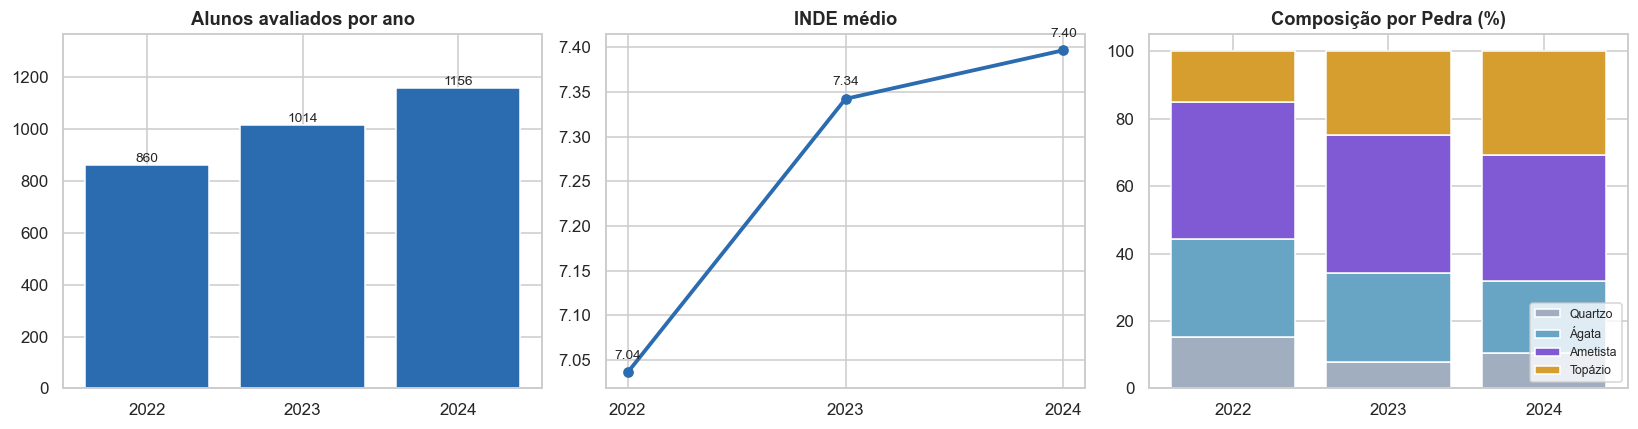

pedra,Quartzo,Ágata,Ametista,Topázio
ano,,,,
2022,15.300,29.100,40.500,15.100
2023,7.700,26.400,40.900,24.900
2024,10.600,21.300,37.100,30.900


In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

# alunos atendidos
serie_alunos = painel.groupby("ano")["id_aluno"].nunique()
eixos[0].bar(serie_alunos.index.astype(str), serie_alunos.values, color=COR["principal"])
for x, v in zip(serie_alunos.index.astype(str), serie_alunos.values):
    eixos[0].text(x, v + 12, str(v), ha="center", fontsize=9)
eixos[0].set_title("Alunos avaliados por ano")
eixos[0].set_ylim(0, serie_alunos.max() * 1.18)

# INDE médio
inde_medio = painel.groupby("ano")["inde"].mean()
eixos[1].plot(inde_medio.index, inde_medio.values, "o-", lw=2.5, color=COR["principal"])
for ano, valor in inde_medio.items():
    eixos[1].annotate(f"{valor:.2f}", (ano, valor), textcoords="offset points",
                      xytext=(0, 9), ha="center", fontsize=9)
eixos[1].set_title("INDE médio")
eixos[1].set_xticks(ANOS)

# composição por pedra
composicao = (
    pd.crosstab(painel["ano"], painel["pedra"], normalize="index")
    .reindex(columns=ORDEM_PEDRA) * 100
)
base = np.zeros(len(composicao))
for pedra in ORDEM_PEDRA:
    eixos[2].bar(composicao.index.astype(str), composicao[pedra], bottom=base,
                 color=PALETA_PEDRA[pedra], label=pedra)
    base += composicao[pedra].values
eixos[2].set_title("Composição por Pedra (%)")
eixos[2].legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

display(composicao.round(1))

---
## Pergunta 1 - Adequação do nível (IAN)

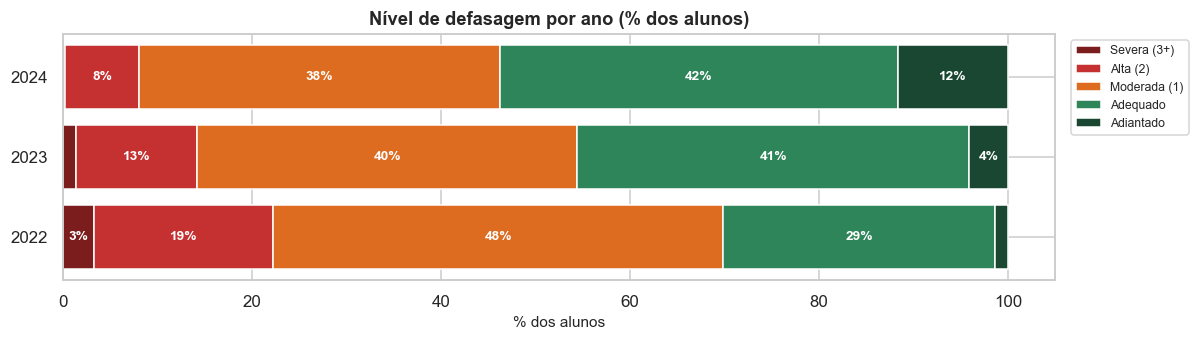

nivel_defasagem,Severa (3+),Alta (2),Moderada (1),Adequado,Adiantado
ano,,,,,
2022,3.300,19.000,47.700,28.700,1.400
2023,1.400,12.800,40.200,41.400,4.100
2024,0.300,7.800,38.100,42.100,11.700


Contagem absoluta de alunos defasados:


,sum,mean
ano,,
2022,601,0.699
2023,552,0.544
2024,534,0.462


In [25]:
dist_defasagem = (
    pd.crosstab(painel["ano"], painel["nivel_defasagem"], normalize="index")
    .reindex(columns=ROTULO_DEFASAGEM) * 100
)
cores_defasagem = ["#7b1d1d", COR["alerta"], COR["atencao"], COR["ok"], "#1a4731"]

fig, eixo = plt.subplots(figsize=(11, 3.2))
base = np.zeros(len(dist_defasagem))
for rotulo, cor in zip(ROTULO_DEFASAGEM, cores_defasagem):
    valores = dist_defasagem[rotulo].values
    eixo.barh(dist_defasagem.index.astype(str), valores, left=base, color=cor, label=rotulo)
    for y, (b, v) in enumerate(zip(base, valores)):
        if v > 3:
            eixo.text(b + v / 2, y, f"{v:.0f}%", ha="center", va="center",
                      color="white", fontsize=9, fontweight="bold")
    base += valores
eixo.set_title("Nível de defasagem por ano (% dos alunos)")
eixo.set_xlabel("% dos alunos")
eixo.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

display(dist_defasagem.round(1))
print("Contagem absoluta de alunos defasados:")
display(painel.groupby("ano")["defasado"].agg(["sum", "mean"]).round(3))

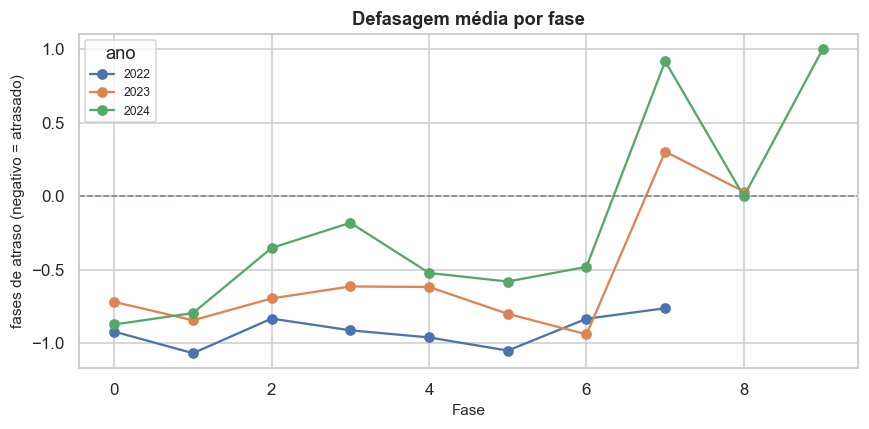

In [26]:
# onde a defasagem se concentra
media_defasagem = painel.groupby(["ano", "fase"])["defasagem"].mean().unstack(0)

fig, eixo = plt.subplots(figsize=(8, 4))
media_defasagem.plot(ax=eixo, marker="o")
eixo.axhline(0, color=COR["neutro"], ls="--", lw=1)
eixo.set_title("Defasagem média por fase")
eixo.set_xlabel("Fase")
eixo.set_ylabel("fases de atraso (negativo = atrasado)")
eixo.legend(title="ano", fontsize=8)

plt.tight_layout()
plt.show()

## Pergunta 2 - Desempenho acadêmico (IDA)

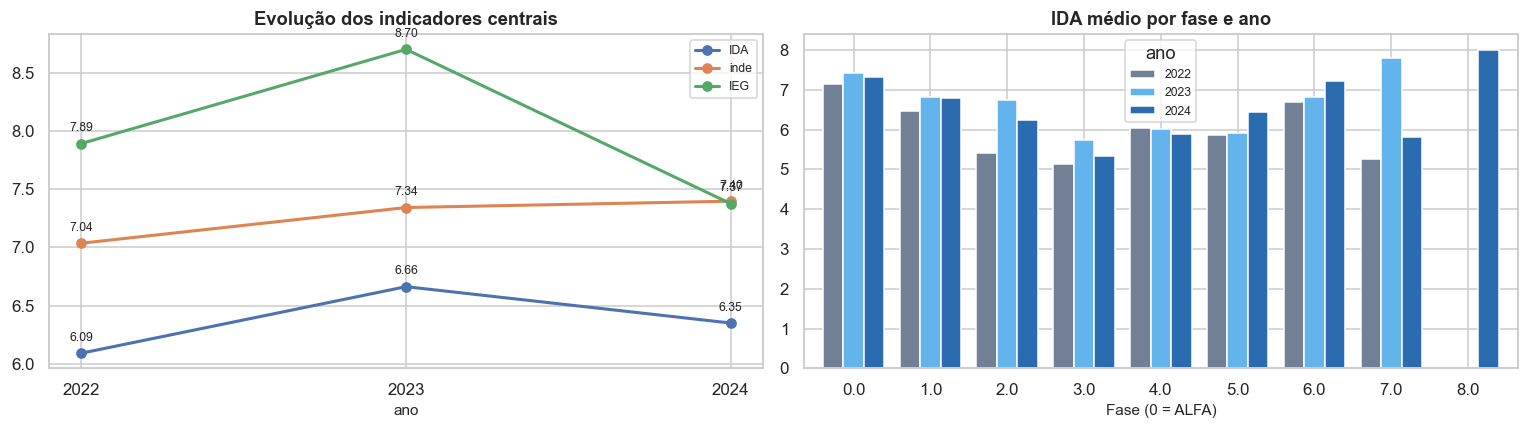

,IDA,IEG,IPS,IAA,IPV,IAN,inde
ano,,,,,,,
2022,6.093,7.891,6.905,8.274,7.254,6.424,7.036
2023,6.663,8.699,5.120,6.903,8.028,7.244,7.342
2024,6.351,7.375,6.830,8.544,7.354,7.684,7.397


In [27]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 4))

# evolução do IDA e do INDE
serie = painel.groupby("ano")[["IDA", "inde", "IEG"]].mean()
serie.plot(ax=eixos[0], marker="o", lw=2)
for coluna in serie.columns:
    for ano, valor in serie[coluna].items():
        eixos[0].annotate(f"{valor:.2f}", (ano, valor), textcoords="offset points",
                          xytext=(0, 8), ha="center", fontsize=8)
eixos[0].set_title("Evolução dos indicadores centrais")
eixos[0].set_xticks(ANOS)
eixos[0].legend(fontsize=8)

# IDA por fase
ida_fase = painel.pivot_table(index="fase", columns="ano", values="IDA", aggfunc="mean")
ida_fase.plot(kind="bar", ax=eixos[1], width=0.8,
              color=[COR["neutro"], COR["apoio"], COR["principal"]])
eixos[1].set_title("IDA médio por fase e ano")
eixos[1].set_xlabel("Fase (0 = ALFA)")
eixos[1].tick_params(axis="x", rotation=0)
eixos[1].legend(title="ano", fontsize=8)

plt.tight_layout()
plt.show()

display(painel.groupby("ano")[["IDA", "IEG", "IPS", "IAA", "IPV", "IAN", "inde"]]
        .mean().round(3))

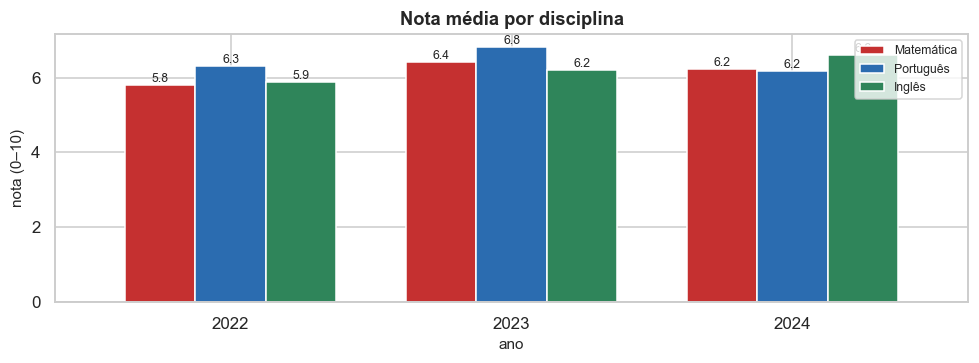

,nota_mat,nota_por,nota_ing
ano,,,
2022,5.810,6.320,5.880
2023,6.410,6.820,6.200
2024,6.230,6.180,6.600


In [28]:
# notas por disciplina
notas = painel.groupby("ano")[["nota_mat", "nota_por", "nota_ing"]].mean()
eixo = notas.plot(kind="bar", figsize=(9, 3.4), width=0.75,
                  color=[COR["alerta"], COR["principal"], COR["ok"]])
eixo.set_title("Nota média por disciplina")
eixo.set_ylabel("nota (0–10)")
eixo.tick_params(axis="x", rotation=0)
eixo.legend(["Matemática", "Português", "Inglês"], fontsize=8)
for container in eixo.containers:
    eixo.bar_label(container, fmt="%.1f", fontsize=8)
plt.tight_layout()
plt.show()

display(notas.round(2))

## Pergunta 3 - Engajamento nas atividades (IEG)

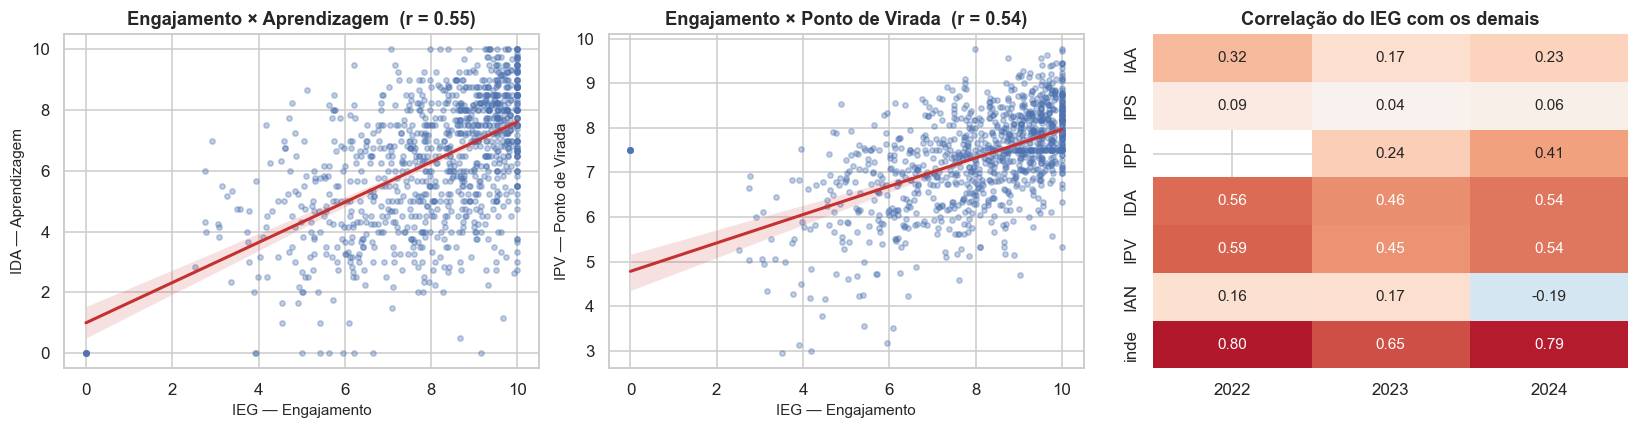

In [29]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

dados_2024 = painel[painel["ano"] == 2024].dropna(subset=["IEG", "IDA", "IPV"])

for eixo, (x, y) in zip(eixos[:2], [("IEG", "IDA"), ("IEG", "IPV")]):
    sns.regplot(data=dados_2024, x=x, y=y, ax=eixo, scatter_kws={"s": 12, "alpha": 0.35},
                line_kws={"color": COR["alerta"], "lw": 2})
    r = dados_2024[x].corr(dados_2024[y])
    eixo.set_title(f"{NOME_INDICADOR[x]} × {NOME_INDICADOR[y]}  (r = {r:.2f})")
    eixo.set_xlabel(f"{x} — {NOME_INDICADOR[x]}")
    eixo.set_ylabel(f"{y} — {NOME_INDICADOR[y]}")

# correlação do IEG com todo o resto, ano a ano
correlacoes = pd.DataFrame({
    ano: painel[painel["ano"] == ano][INDICADORES + ["inde"]].corr()["IEG"]
    for ano in ANOS
}).drop("IEG")
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=eixos[2], cbar=False)
eixos[2].set_title("Correlação do IEG com os demais")

plt.tight_layout()
plt.show()

In [30]:
# o engajamento traduz-se em desempenho? faixas de IEG × IDA médio
faixas = pd.cut(painel["IEG"], bins=[0, 5, 6, 7, 8, 9, 10],
                labels=["<5", "5–6", "6–7", "7–8", "8–9", "9–10"])
tabela = painel.groupby(faixas, observed=True).agg(
    alunos=("IEG", "size"),
    IDA_medio=("IDA", "mean"),
    IPV_medio=("IPV", "mean"),
    INDE_medio=("inde", "mean"),
    pct_defasado=("defasado", "mean"),
).round(2)
tabela["pct_defasado"] = (tabela["pct_defasado"] * 100).round(1)
display(tabela)

,alunos,IDA_medio,IPV_medio,INDE_medio,pct_defasado
IEG,,,,,
<5,129,3.630,5.890,5.300,78.000
5–6,150,4.820,6.510,6.130,64.000
6–7,248,5.140,6.870,6.440,67.000
7–8,467,5.880,7.250,6.930,65.000
8–9,758,6.560,7.600,7.340,62.000
9–10,1092,7.310,8.130,7.960,50.000


## Pergunta 4 - Autoavaliação (IAA)

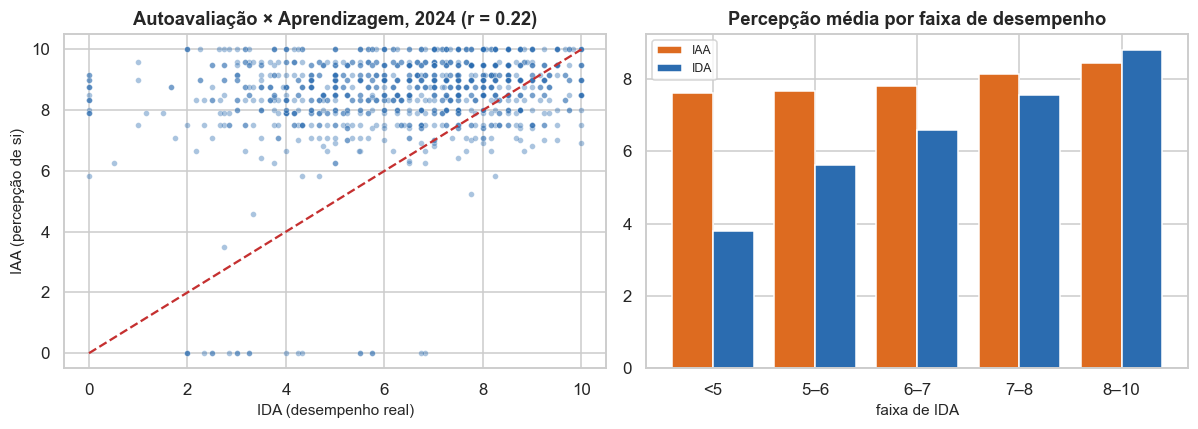

Correlação IAA × IDA por ano: {2022: 0.21, 2023: 0.1, 2024: 0.22}
Correlação IAA × IEG por ano: {2022: 0.32, 2023: 0.17, 2024: 0.23}


In [31]:
dados = painel.dropna(subset=["IAA", "IDA"]).copy()
dados["diferenca"] = dados["IAA"] - dados["IDA"]

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(data=dados[dados["ano"] == 2024], x="IDA", y="IAA", ax=eixos[0],
                s=14, alpha=0.4, color=COR["principal"])
eixos[0].plot([0, 10], [0, 10], ls="--", color=COR["alerta"], lw=1.5)
r_2024 = dados[dados['ano'] == 2024]['IAA'].corr(dados[dados['ano'] == 2024]['IDA'])
eixos[0].set_title(f"Autoavaliação × Aprendizagem, 2024 (r = {r_2024:.2f})")
eixos[0].set_xlabel("IDA (desempenho real)")
eixos[0].set_ylabel("IAA (percepção de si)")

perfil = dados.groupby(pd.cut(dados["IDA"], bins=[0, 5, 6, 7, 8, 10],
                              labels=["<5", "5–6", "6–7", "7–8", "8–10"]),
                       observed=True)[["IAA", "IDA"]].mean()
perfil.plot(kind="bar", ax=eixos[1], color=[COR["atencao"], COR["principal"]], width=0.8)
eixos[1].set_title("Percepção média por faixa de desempenho")
eixos[1].set_xlabel("faixa de IDA")
eixos[1].tick_params(axis="x", rotation=0)
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Correlação IAA × IDA por ano: "
      f"{ {a: round(painel[painel.ano==a]['IAA'].corr(painel[painel.ano==a]['IDA']), 2) for a in ANOS} }")
print(f"Correlação IAA × IEG por ano: "
      f"{ {a: round(painel[painel.ano==a]['IAA'].corr(painel[painel.ano==a]['IEG']), 2) for a in ANOS} }")


## Pergunta 5 - Aspectos psicossociais (IPS)

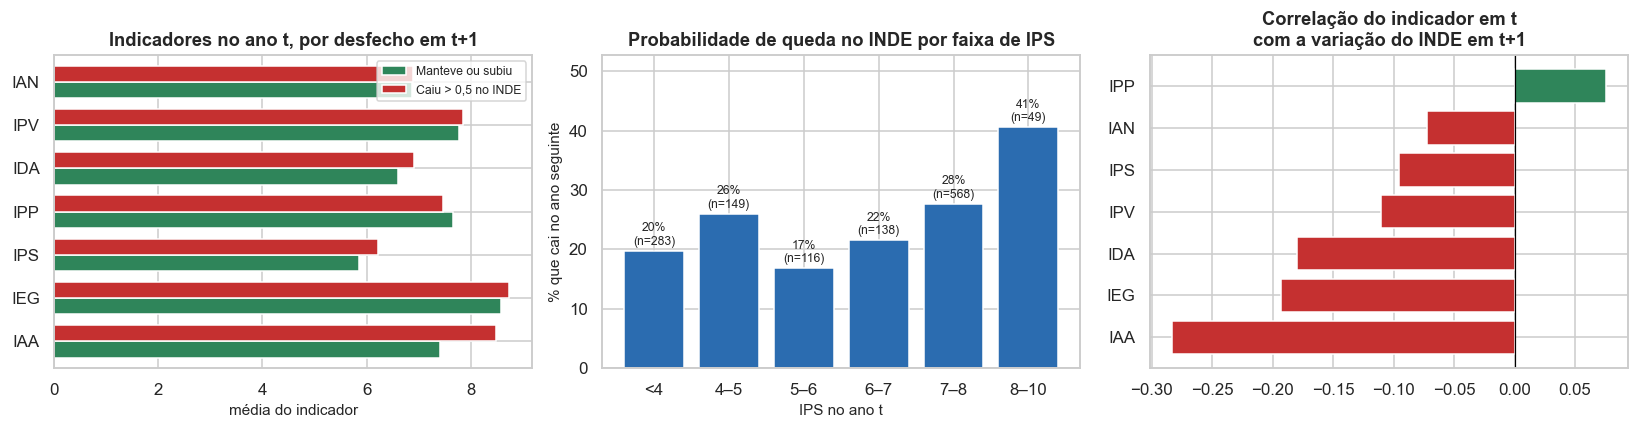

In [32]:
# comparar o IPS de hoje com o que acontece no ano seguinte
com_futuro = painel_f[painel_f["tem_ano_seguinte"]].copy()
com_futuro["caiu_inde"] = com_futuro["var_inde"] < -0.5
com_futuro["piorou_defasagem"] = com_futuro["var_defasagem"] < 0

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

# IPS atual × queda futura
comparativo = com_futuro.groupby("caiu_inde")[INDICADORES].mean().T
comparativo.columns = ["Manteve ou subiu", "Caiu > 0,5 no INDE"]
comparativo.plot(kind="barh", ax=eixos[0], color=[COR["ok"], COR["alerta"]], width=0.75)
eixos[0].set_title("Indicadores no ano t, por desfecho em t+1")
eixos[0].set_xlabel("média do indicador")
eixos[0].legend(fontsize=8)

# faixas de IPS × probabilidade de queda
faixa_ips = pd.cut(com_futuro["IPS"], bins=[0, 4, 5, 6, 7, 8, 10],
                   labels=["<4", "4–5", "5–6", "6–7", "7–8", "8–10"])
risco_ips = com_futuro.groupby(faixa_ips, observed=True).agg(
    alunos=("IPS", "size"), pct_queda=("caiu_inde", "mean"),
)
eixos[1].bar(risco_ips.index.astype(str), risco_ips["pct_queda"] * 100,
             color=COR["principal"])
for x, (v, n) in enumerate(zip(risco_ips["pct_queda"] * 100, risco_ips["alunos"])):
    eixos[1].text(x, v + 1, f"{v:.0f}%\n(n={n})", ha="center", fontsize=8)
eixos[1].set_title("Probabilidade de queda no INDE por faixa de IPS")
eixos[1].set_xlabel("IPS no ano t")
eixos[1].set_ylabel("% que cai no ano seguinte")
eixos[1].set_ylim(0, risco_ips["pct_queda"].max() * 130)

# correlação de cada indicador em t com a variação futura
correl_futuro = pd.Series({
    ind: com_futuro[ind].corr(com_futuro["var_inde"]) for ind in INDICADORES
}).sort_values()
cores = [COR["alerta"] if v < 0 else COR["ok"] for v in correl_futuro]
eixos[2].barh(correl_futuro.index, correl_futuro.values, color=cores)
eixos[2].axvline(0, color="black", lw=0.8)
eixos[2].set_title("Correlação do indicador em t\ncom a variação do INDE em t+1")

plt.tight_layout()
plt.show()

## Pergunta 6 - Aspectos psicopedagógicos (IPP)

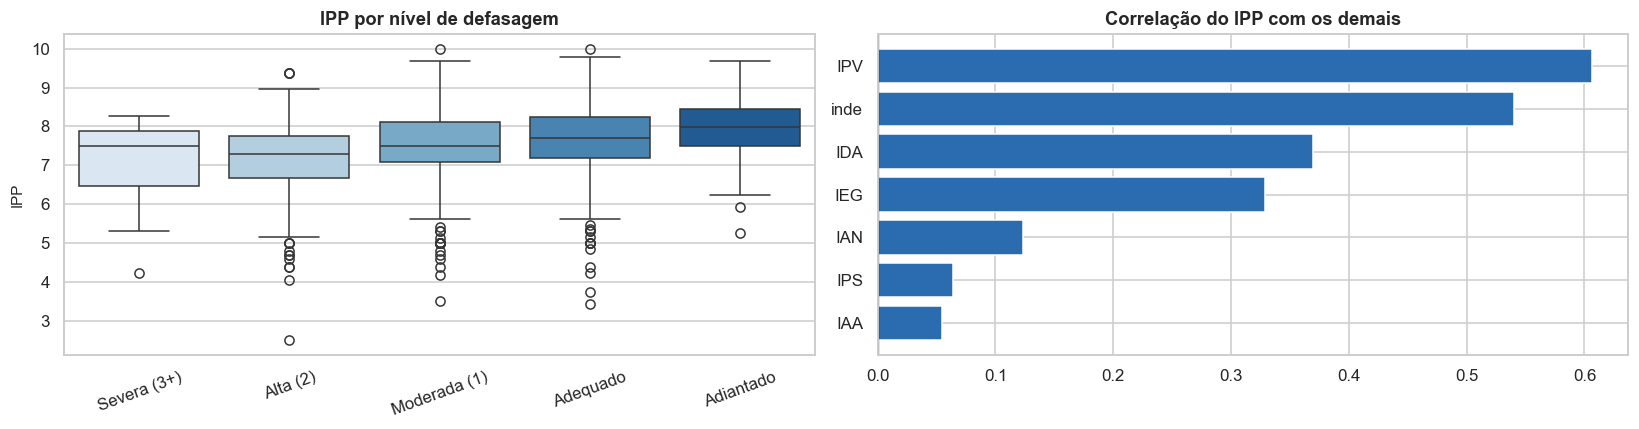

,alunos,IPP_medio,IAN_medio,IDA_medio
nivel_defasagem,,,,
Severa (3+),17,7.010,2.500,5.100
Alta (2),220,7.110,5.000,5.890
Moderada (1),847,7.550,5.000,6.500
Adequado,780,7.640,10.000,6.640
Adiantado,128,7.930,10.000,6.850


In [33]:
dados_ipp = painel.dropna(subset=["IPP", "IAN"])

fig, eixos = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(data=dados_ipp, x="nivel_defasagem", y="IPP", ax=eixos[0],
            order=[r for r in ROTULO_DEFASAGEM if r in dados_ipp["nivel_defasagem"].unique()],
            palette="Blues")
eixos[0].set_title("IPP por nível de defasagem")
eixos[0].set_xlabel("")
eixos[0].tick_params(axis="x", rotation=20)


correl_ipp = dados_ipp[INDICADORES + ["inde"]].corr()["IPP"].drop("IPP").sort_values()
eixos[1].barh(correl_ipp.index, correl_ipp.values, color=COR["principal"])
eixos[1].set_title("Correlação do IPP com os demais")
eixos[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

display(dados_ipp.groupby("nivel_defasagem", observed=True)
        .agg(alunos=("IPP", "size"), IPP_medio=("IPP", "mean"),
             IAN_medio=("IAN", "mean"), IDA_medio=("IDA", "mean")).round(2))

## Pergunta 7 - Ponto de virada (IPV)

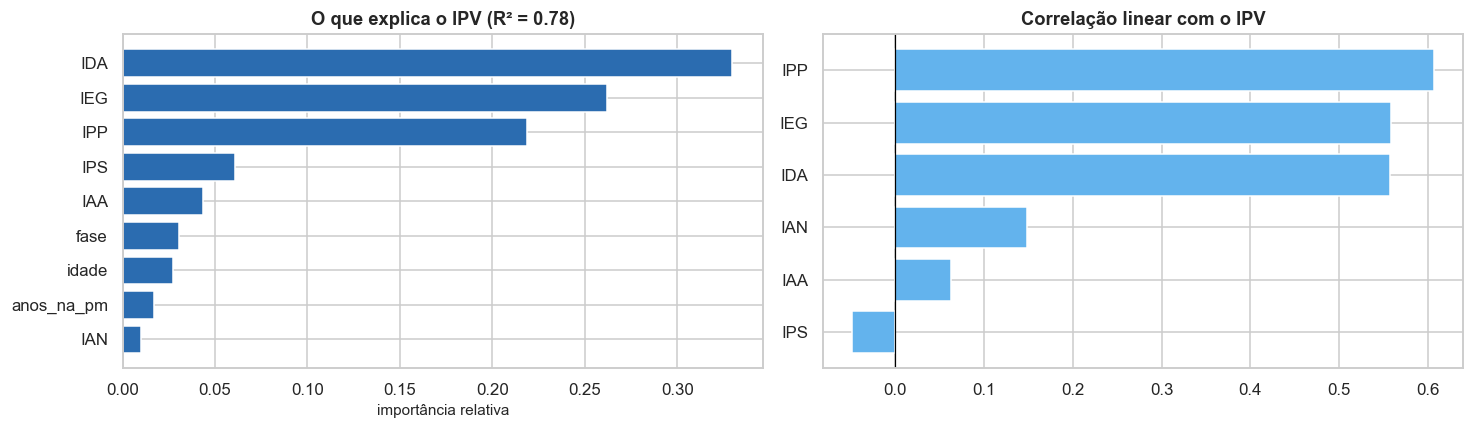

Importância (%):
IDA          33.000
IEG          26.200
IPP          21.900
IPS           6.100
IAA           4.400
fase          3.100
idade         2.700
anos_na_pm    1.700
IAN           1.000


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# como 'Atingiu PV' só existe em 2022, trabalhamos com o indicador numérico IPV
preditoras = ["IAA", "IEG", "IPS", "IPP", "IDA", "IAN", "idade", "anos_na_pm", "fase"]
dados_ipv = painel.dropna(subset=["IPV"])
X_ipv = SimpleImputer(strategy="median").fit_transform(dados_ipv[preditoras])
y_ipv = dados_ipv["IPV"]

floresta = RandomForestRegressor(n_estimators=400, min_samples_leaf=5,
                                 random_state=SEMENTE).fit(X_ipv, y_ipv)
importancias = pd.Series(floresta.feature_importances_, index=preditoras).sort_values()

fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4))
eixos[0].barh(importancias.index, importancias.values, color=COR["principal"])
eixos[0].set_title(f"O que explica o IPV (R² = {floresta.score(X_ipv, y_ipv):.2f})")
eixos[0].set_xlabel("importância relativa")

correl_ipv = dados_ipv[INDICADORES].corr()["IPV"].drop("IPV").sort_values()
eixos[1].barh(correl_ipv.index, correl_ipv.values, color=COR["apoio"])
eixos[1].set_title("Correlação linear com o IPV")
eixos[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

print("Importância (%):")
print((importancias.sort_values(ascending=False) * 100).round(1).to_string())

## Pergunta 8 - Multidimensionalidade dos indicadores

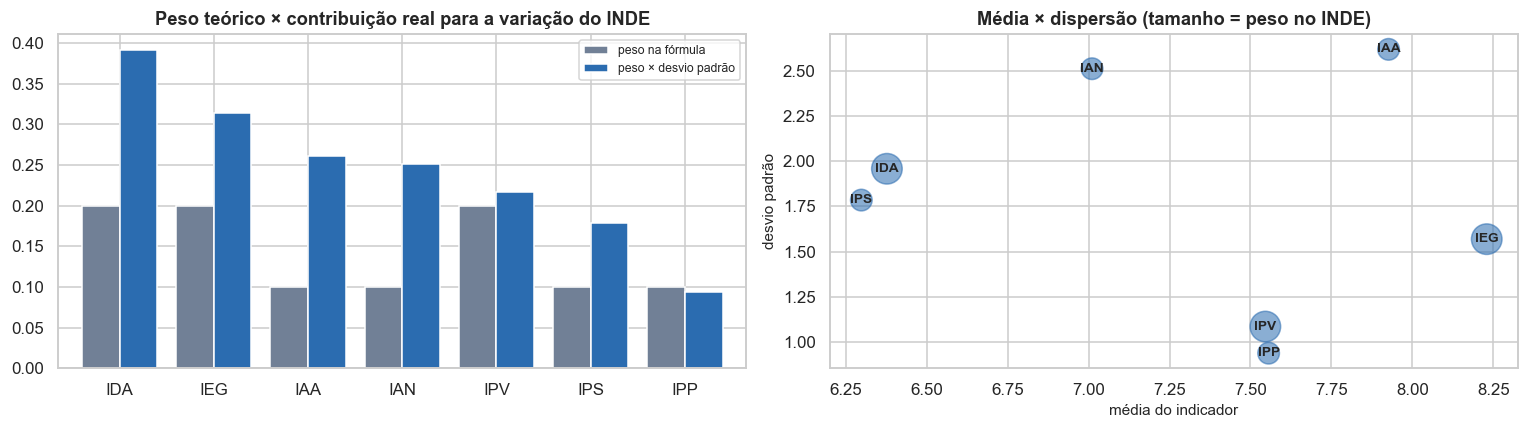

In [35]:
PESOS_DIVULGADOS = {"IAN": 0.10, "IDA": 0.20, "IEG": 0.20, "IAA": 0.10,
                    "IPS": 0.10, "IPP": 0.10, "IPV": 0.20}

dados_inde = painel.dropna(subset=["inde"])
analise = pd.DataFrame({
    "peso_no_INDE": pd.Series(PESOS_DIVULGADOS),
    "correlacao": dados_inde[INDICADORES].corrwith(dados_inde["inde"]),
    "desvio_padrao": dados_inde[INDICADORES].std(),
    "media": dados_inde[INDICADORES].mean(),
})
analise["contribuicao_pratica"] = analise["peso_no_INDE"] * analise["desvio_padrao"]
analise = analise.sort_values("contribuicao_pratica", ascending=False)

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))
analise[["peso_no_INDE", "contribuicao_pratica"]].plot(
    kind="bar", ax=eixos[0], color=[COR["neutro"], COR["principal"]], width=0.8)
eixos[0].set_title("Peso teórico × contribuição real para a variação do INDE")
eixos[0].tick_params(axis="x", rotation=0)
eixos[0].legend(["peso na fórmula", "peso × desvio padrão"], fontsize=8)

eixos[1].scatter(analise["media"], analise["desvio_padrao"],
                 s=analise["peso_no_INDE"] * 2000, alpha=0.55, color=COR["principal"])
for indicador, linha in analise.iterrows():
    eixos[1].annotate(indicador, (linha["media"], linha["desvio_padrao"]),
                      ha="center", va="center", fontsize=9, fontweight="bold")
eixos[1].set_title("Média × dispersão (tamanho = peso no INDE)")
eixos[1].set_xlabel("média do indicador")
eixos[1].set_ylabel("desvio padrão")

plt.tight_layout()
plt.show()

In [36]:
# perfil dos alunos no topo: o que distingue um Topázio de um Ametista?
perfil_pedra = painel.groupby("pedra", observed=True)[INDICADORES + ["inde"]].mean().T
perfil_pedra["salto_Ametista→Topázio"] = perfil_pedra["Topázio"] - perfil_pedra["Ametista"]
display(perfil_pedra.round(2).sort_values("salto_Ametista→Topázio", ascending=False))

pedra,Quartzo,Ágata,Ametista,Topázio,salto_Ametista→Topázio
IAN,5.660,6.080,7.000,8.620,1.610
IDA,3.460,5.260,6.810,8.180,1.370
inde,5.370,6.590,7.520,8.440,0.920
IPV,6.060,7.030,7.740,8.460,0.720
IAA,5.760,7.230,8.310,9.020,0.710
IEG,5.610,7.590,8.680,9.380,0.710
IPS,5.790,5.990,6.310,6.840,0.530
IPP,6.550,7.190,7.600,8.130,0.530


## Evolução dos alunos

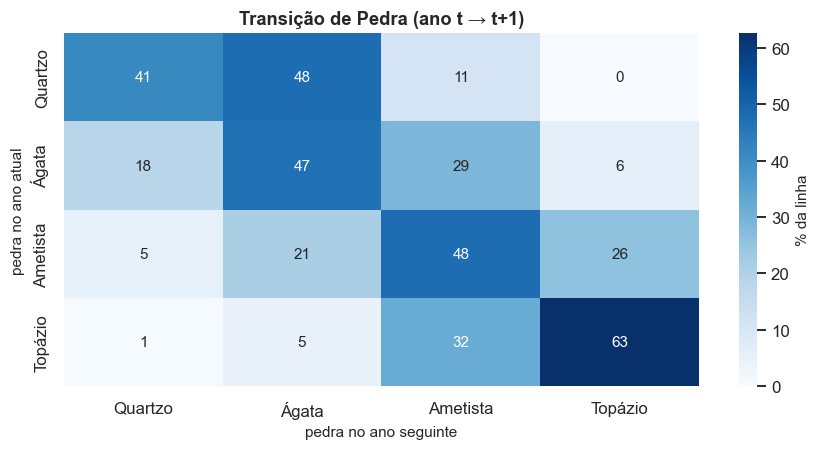

Alunos que SOBEM de pedra: 314 (25.2%)
Alunos que se MANTÊM: 631 (50.6%)
Alunos que DESCEM de pedra: 303 (24.3%)


In [37]:
# matriz de transição entre pedras — em contagem, não em % de linha
transicao_pedra = painel_f.dropna(subset=["pedra", "pedra_prox"])
contagem = (
    pd.crosstab(transicao_pedra["pedra"], transicao_pedra["pedra_prox"])
    .reindex(index=ORDEM_PEDRA, columns=ORDEM_PEDRA).fillna(0)
)
matriz = contagem.div(contagem.sum(axis=1), axis=0) * 100

fig, eixo = plt.subplots(figsize=(8, 4.2))
sns.heatmap(matriz, annot=True, fmt=".0f", cmap="Blues", ax=eixo,
            cbar_kws={"label": "% da linha"})
eixo.set_title("Transição de Pedra (ano t → t+1)")
eixo.set_xlabel("pedra no ano seguinte")
eixo.set_ylabel("pedra no ano atual")

plt.tight_layout()
plt.show()

valores = contagem.values
subiu, manteve, desceu = np.tril(valores, -1).sum(), np.trace(valores), np.triu(valores, 1).sum()
total = valores.sum()
print(f"Alunos que SOBEM de pedra: {subiu:.0f} ({subiu/total:.1%})")
print(f"Alunos que se MANTÊM: {manteve:.0f} ({manteve/total:.1%})")
print(f"Alunos que DESCEM de pedra: {desceu:.0f} ({desceu/total:.1%})")


In [38]:
linhas = []
for ano in (2023, 2024):
    entrantes = painel[(painel["ano"] == ano) & (painel["ano_ingresso"] == ano)]
    veteranos = painel[(painel["ano"] == ano) & (painel["ano_ingresso"] < ano)]
    linhas.append({"ano": ano, "grupo": "ingressantes",
                   "alunos": len(entrantes), "INDE": entrantes["inde"].mean()})
    linhas.append({"ano": ano, "grupo": "veteranos",
                   "alunos": len(veteranos), "INDE": veteranos["inde"].mean()})
display(pd.DataFrame(linhas).round(3))

# e quem saiu do programa depois de 2022?
saiu = set(painel.loc[painel["ano"] == 2022, "id_aluno"]) - set(painel.loc[painel["ano"] == 2023, "id_aluno"])
base_2022 = painel[painel["ano"] == 2022]
print(f"Alunos de 2022 que NÃO retornaram em 2023: {len(saiu)} | INDE médio {base_2022.loc[base_2022['id_aluno'].isin(saiu), 'inde'].mean():.3f}")
print(f"Alunos de 2022 que permaneceram: {860 - len(saiu)} | INDE médio {base_2022.loc[~base_2022['id_aluno'].isin(saiu), 'inde'].mean():.3f}")

,ano,grupo,alunos,INDE
0,2023,ingressantes,360,7.519
1,2023,veteranos,654,7.233
2,2024,ingressantes,349,7.415
3,2024,veteranos,807,7.387


Alunos de 2022 que NÃO retornaram em 2023: 260 | INDE médio 6.513
Alunos de 2022 que permaneceram: 600 | INDE médio 7.263


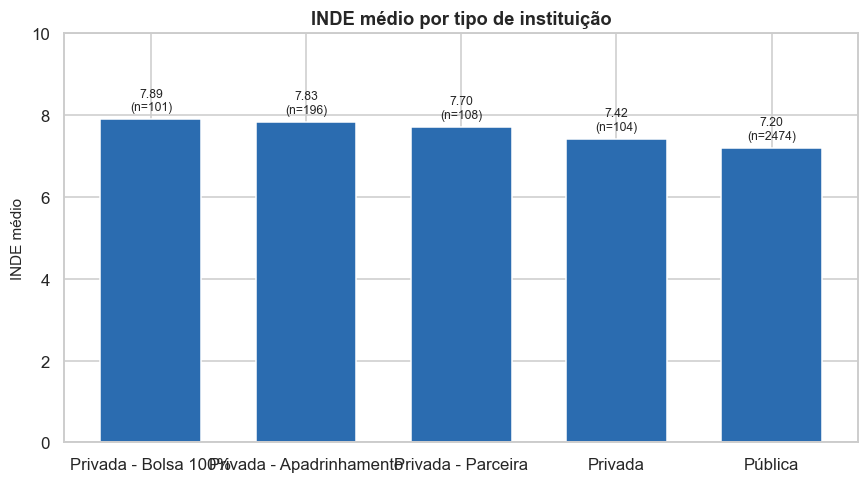

In [39]:
fig, eixo = plt.subplots(figsize=(8, 4.5))

# instituição de ensino
principais = painel["instituicao"].value_counts().head(5).index
por_instituicao = (
    painel[painel["instituicao"].isin(principais)]
    .groupby("instituicao").agg(inde=("inde", "mean"), alunos=("inde", "size"))
    .sort_values("inde", ascending=False)
)
eixo.bar(por_instituicao.index, por_instituicao["inde"], color=COR["principal"], width=0.65)
for x, (v, n) in enumerate(zip(por_instituicao["inde"], por_instituicao["alunos"])):
    eixo.text(x, v + 0.15, f"{v:.2f}\n(n={n})", ha="center", va="bottom", fontsize=8)
eixo.set_title("INDE médio por tipo de instituição")
eixo.set_ylabel("INDE médio")
eixo.set_ylim(0, 10)
eixo.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## Pontos de atenção 

In [40]:
# Alunos com engajamento alto e aprendizagem baixa
ultimo = painel[painel["ano"] == 2024].dropna(subset=["IEG", "IDA"])
ultimo = ultimo.assign(
    grupo=np.select(
        [
            (ultimo["IEG"] >= 7) & (ultimo["IDA"] >= 6),
            (ultimo["IEG"] >= 7) & (ultimo["IDA"] < 6),
            (ultimo["IEG"] < 7) & (ultimo["IDA"] >= 6),
        ],
        ["Engajado e aprendendo", "Engajado mas travado", "Aprende sem engajar"],
        default="Precisa de atenção",
    )
)
quadro = ultimo.groupby("grupo").agg(
    alunos=("inde", "size"), INDE=("inde", "mean"), IEG=("IEG", "mean"),
    IDA=("IDA", "mean"), IPS=("IPS", "mean"), pct_defasado=("defasado", "mean"),
).round(2)
quadro["pct_defasado"] = (quadro["pct_defasado"] * 100).round(1)
quadro["% do total"] = (quadro["alunos"] / len(ultimo) * 100).round(1)
display(quadro.sort_values("alunos", ascending=False))

,alunos,INDE,IEG,IDA,IPS,pct_defasado,% do total
grupo,,,,,,,
Engajado e aprendendo,585,8.040,9.030,7.810,6.890,49.000,55.500
Engajado mas travado,228,7.010,8.460,4.420,6.900,50.000,21.600
Precisa de atenção,174,5.940,5.280,3.670,6.730,53.000,16.500
Aprende sem engajar,68,6.860,5.790,7.130,6.260,57.000,6.400


---
# 4. Previsão de risco com Machine Learning

**Objetivo:** desenvolver um modelo que estime a probabilidade de um aluno entrar em risco de defasagem no ciclo seguinte, para que a Passos Mágicos possa priorizar o acompanhamento antes que a queda aconteça.


In [41]:
# Bibliotecas de Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Ferramentas para medir a qualidade do modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

### Montagem da base de modelagem

Cada linha é um aluno observado em dois anos consecutivos: as *features* vêm do ano `t` e
o rótulo do ano `t+1`. Alunos que aparecem em um único ano ficam de fora, porque não há
como saber o que aconteceu com eles depois.

In [42]:
COLUNAS_MODELO = ["id_aluno", "ano", "genero", "idade", "anos_na_pm", "instituicao", "fase", "fase_ideal", "defasagem", "inde", "pedra", *INDICADORES, "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores"]

transicoes = painel_f[painel_f["defasagem_prox"].notna()][COLUNAS_MODELO + ["defasagem_prox", "inde_prox", "fase_prox", "var_defasagem", "var_inde"]].copy().reset_index(drop=True)

print(f"Pares aluno (ano t → ano t+1): {len(transicoes)}")
print(f"Alunos distintos: {transicoes['id_aluno'].nunique()}")

Pares aluno (ano t → ano t+1): 1365
Alunos distintos: 897


### Definição da variável alvo

O alvo não vem pronto na base, precisa ser construído. Considero que o aluno **entrou em risco de defasagem** quando as duas condições acontecem juntas no ano seguinte:

1. a defasagem **piorou** em relação ao ano atual (`var_defasagem < 0`);
2. ele **termina defasado** (`defasagem_prox < 0`).

A segunda condição existe para não contar como risco quem apenas deixou de estar adiantado e passou a estar em dia, o número em si diminuiu mas ainda esta com um resultado positivo

Também vale registrar por que o alvo **não** é o Ponto de Virada: o campo `Atingiu PV`
está 100% vazio em 2023 e 2024 (Conclusão 1 da Parte 1). Sem rótulo nos anos recentes não
haveria como treinar nem validar o modelo.

In [43]:
COLUNA_ALVO = "risco"

# entrou em defasagem ou aprofundou a que já tinha
transicoes[COLUNA_ALVO] = ((transicoes["var_defasagem"] < 0) & (transicoes["defasagem_prox"] < 0)).astype(int)

print(f"Prevalência do alvo: {transicoes[COLUNA_ALVO].mean():.1%} ({transicoes[COLUNA_ALVO].sum()} de {len(transicoes)} pares)")

display(
    transicoes.groupby("ano")[COLUNA_ALVO]
    .agg(pares="size", positivos="sum", prevalencia="mean")
    .round(3)
)

Prevalência do alvo: 15.5% (212 de 1365 pares)


,pares,positivos,prevalencia
ano,,,
2022,600,98,0.163
2023,765,114,0.149


### Distribuição da variável alvo

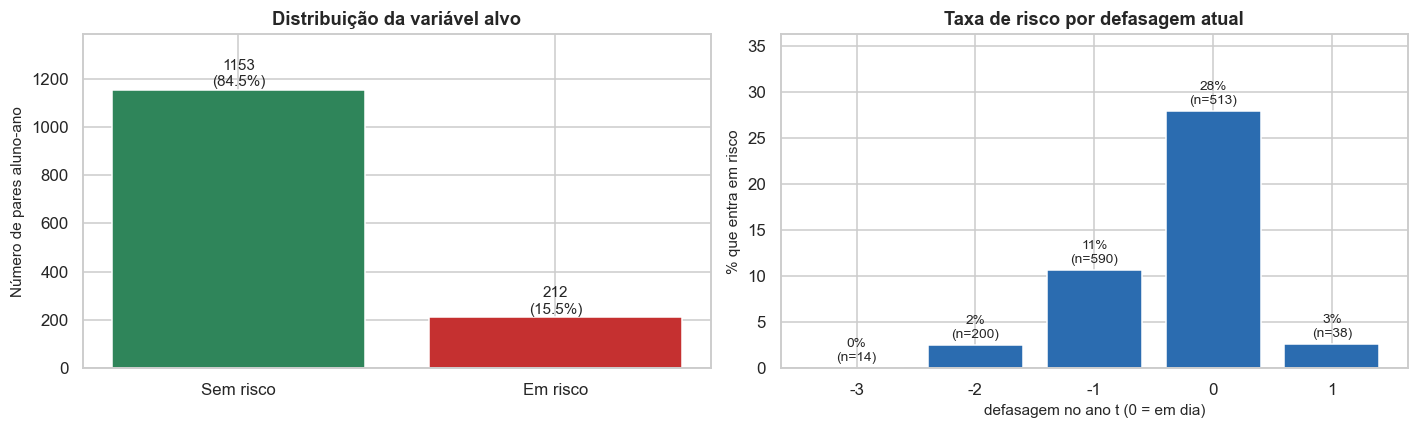

In [44]:
contagem = transicoes[COLUNA_ALVO].value_counts().sort_index()
rotulos = ["Sem risco", "Em risco"]

fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

# distribuição geral
barras = eixos[0].bar(rotulos, contagem.values,
                      color=[COR["ok"], COR["alerta"]], edgecolor="white")
for barra, valor in zip(barras, contagem.values):
    eixos[0].text(barra.get_x() + barra.get_width() / 2, valor + 15,
                  f"{valor}\n({valor/len(transicoes):.1%})",
                  ha="center", fontsize=10)
eixos[0].set_title("Distribuição da variável alvo")
eixos[0].set_ylabel("Número de pares aluno-ano")
eixos[0].set_ylim(0, contagem.max() * 1.2)

# taxa de risco por nível de defasagem atual
taxa = transicoes.groupby("defasagem")[COLUNA_ALVO].agg(["mean", "size"])
taxa = taxa[taxa["size"] >= 10]
eixos[1].bar(taxa.index.astype(int).astype(str), taxa["mean"] * 100,
             color=COR["principal"], edgecolor="white")
for x, (valor, n) in enumerate(zip(taxa["mean"] * 100, taxa["size"])):
    eixos[1].text(x, valor + 0.8, f"{valor:.0f}%\n(n={n})", ha="center", fontsize=9)
eixos[1].set_title("Taxa de risco por defasagem atual")
eixos[1].set_xlabel("defasagem no ano t (0 = em dia)")
eixos[1].set_ylabel("% que entra em risco")
eixos[1].set_ylim(0, taxa["mean"].max() * 130)

plt.tight_layout()
plt.show()

> ### Um achado que muda a leitura do modelo
>
> A taxa de risco é **maior entre os alunos que hoje estão em dia** (28%) e quase nula
> entre os severamente defasados (2,5% em −2, zero em −3).
>
> Não é erro: é um teto estrutural. Quem já está três fases atrás quase não tem para onde
> cair, nesse caso a fase ALFA é o piso. Quem está em dia é justamente quem tem o que perder.
>
> A consequência é importante: **este modelo é um alerta precoce, não um ranking de
> gravidade**. Ele não substitui a lista de alunos já defasados, que sai direto do IAN sem
> precisar de modelo nenhum. Os dois se combinam na matriz de priorização

### Estatísticas descritivas das variáveis

In [45]:
VARIAVEIS_NUMERICAS = ["idade", "anos_na_pm", "fase", "fase_ideal", "defasagem", "inde", "IAA", "IEG", "IPS", "IDA", "IPV", "IAN", "nota_mat", "nota_por", "nota_ing", "qtd_avaliadores"]
VARIAVEIS_CATEGORICAS = ["genero", "instituicao"]

transicoes[VARIAVEIS_NUMERICAS].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
idade,"1,365.000",12.090,3.100,7.000,10.000,12.000,14.000,26.000
anos_na_pm,"1,365.000",1.670,1.860,0.000,0.000,1.000,3.000,7.000
fase,"1,365.000",2.270,2.140,0.000,1.000,2.000,3.000,8.000
fase_ideal,"1,365.000",2.990,2.110,0.000,2.000,3.000,4.000,8.000
defasagem,"1,365.000",-0.720,0.810,-4.000,-1.000,-1.000,0.000,2.000
inde,"1,290.000",7.370,0.880,3.700,6.800,7.460,7.990,9.440
IAA,"1,306.000",7.660,2.990,0.000,7.800,8.800,9.500,10.000
IEG,"1,293.000",8.600,1.200,2.000,8.100,8.900,9.500,10.000
IPS,"1,303.000",5.960,1.910,2.500,5.000,6.900,7.500,10.000
IDA,"1,293.000",6.660,1.690,1.000,5.700,6.900,7.900,10.000


### Gráfico de correlação

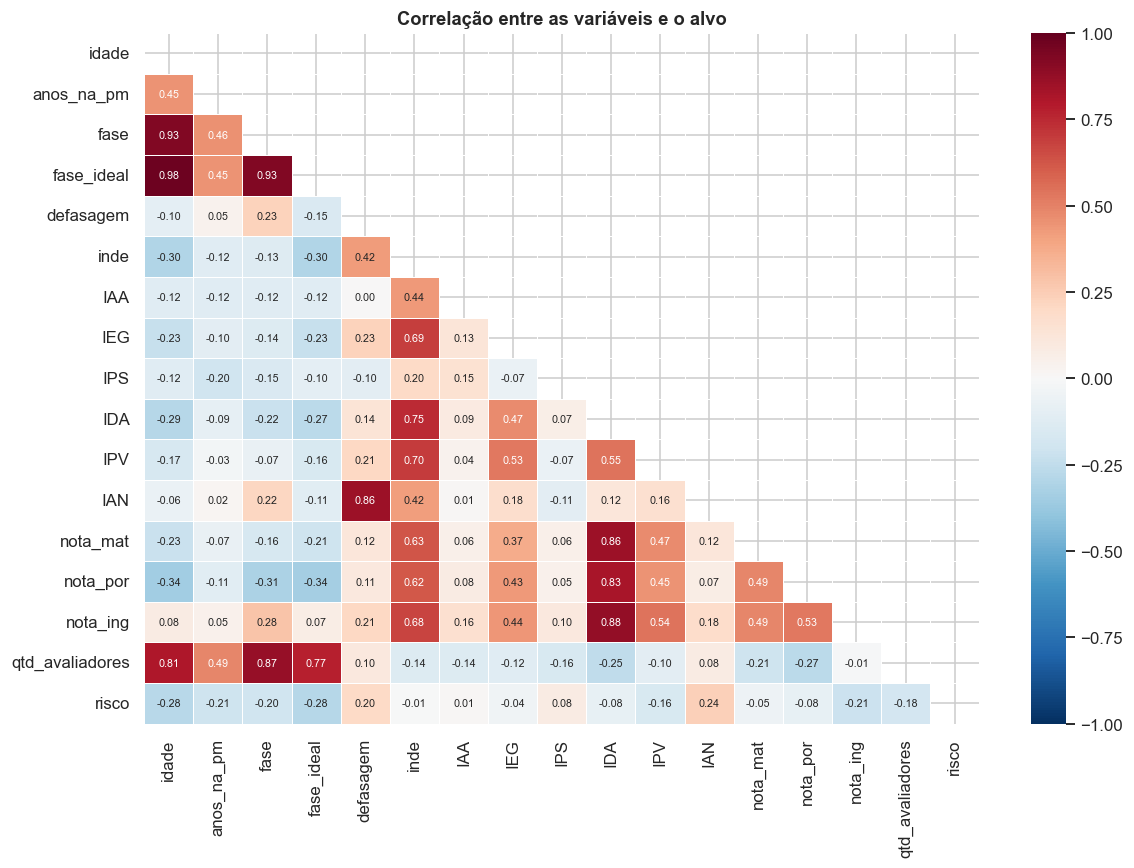

Correlação de cada variável com o alvo:
IAN                0.237
defasagem          0.201
IPS                0.084
IAA                0.014
inde              -0.006
IEG               -0.039
nota_mat          -0.053
nota_por          -0.082
IDA               -0.082
IPV               -0.158
qtd_avaliadores   -0.181
fase              -0.203
anos_na_pm        -0.207
nota_ing          -0.211
idade             -0.275
fase_ideal        -0.284


In [46]:
plt.figure(figsize=(11, 8))
correlacao = transicoes[VARIAVEIS_NUMERICAS + [COLUNA_ALVO]].corr()
mascara = np.triu(np.ones_like(correlacao, dtype=bool))  # oculta a metade espelhada
sns.heatmap(correlacao, mask=mascara, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlação entre as variáveis e o alvo")
plt.tight_layout()
plt.show()

print("Correlação de cada variável com o alvo:")
print(correlacao[COLUNA_ALVO].drop(COLUNA_ALVO).sort_values(ascending=False).round(3).to_string())

Nenhuma variável isolada tem correlação forte com o alvo, a maior em valor absoluto é fase_ideal, com −0,28 e seguida de IAN com +0,24. Isso já indica que um modelo linear vai ter dificuldade e que a relação provavelmente é não linear, podendo ser aferida por meio de uma comparação de modelos

### Codificação das variáveis categóricas

In [47]:
dados_modelo = transicoes.copy()

print(f"Colunas categóricas (features): {VARIAVEIS_CATEGORICAS}")
print(f"Coluna alvo: {COLUNA_ALVO}")

encoders = {}

for coluna in VARIAVEIS_CATEGORICAS:
    le = LabelEncoder()
    dados_modelo[coluna] = le.fit_transform(dados_modelo[coluna].astype(str))
    encoders[coluna] = le
    print(f"\n{coluna} (números → categorias):")
    for i, categoria in enumerate(le.classes_):
        print(f"  {i} → {categoria}")

Colunas categóricas (features): ['genero', 'instituicao']
Coluna alvo: risco

genero (números → categorias):
  0 → F
  1 → M

instituicao (números → categorias):
  0 → Concluiu o 3º EM
  1 → Nenhuma
  2 → Privada
  3 → Privada - Apadrinhamento
  4 → Privada - Bolsa 100%
  5 → Privada - Empresa parceira
  6 → Privada - Parceira
  7 → Pública


### Separação em Features (X) e Target (y)

In [48]:
X = dados_modelo[VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS]
y = dados_modelo[COLUNA_ALVO]

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print(f"\nFeatures utilizadas ({X.shape[1]}):")
for coluna in X.columns:
    tipo = "categórica" if coluna in VARIAVEIS_CATEGORICAS else "numérica"
    print(f"{coluna:18s} ({tipo})")

Formato de X: (1365, 18)
Formato de y: (1365,)

Features utilizadas (18):
idade              (numérica)
anos_na_pm         (numérica)
fase               (numérica)
fase_ideal         (numérica)
defasagem          (numérica)
inde               (numérica)
IAA                (numérica)
IEG                (numérica)
IPS                (numérica)
IDA                (numérica)
IPV                (numérica)
IAN                (numérica)
nota_mat           (numérica)
nota_por           (numérica)
nota_ing           (numérica)
qtd_avaliadores    (numérica)
genero             (categórica)
instituicao        (categórica)


### Treino e Teste

Esta etapa apresenta a principal diferença em relação a um projeto de classificação
convencional: **não é utilizado o `train_test_split` aleatório**.

Há dois motivos para isso. O primeiro é que 468 alunos aparecem tanto na transição 2022→2023 quanto na 2023→2024, de modo que uma divisão aleatória colocaria o mesmo aluno nos dois conjuntos e inflaria as métricas artificialmente. O segundo, e mais relevante, é que o uso real do modelo tem natureza temporal: a associação treina o modelo com o histórico disponível e o aplica à turma atual para priorizar o próximo ciclo. A avaliação precisa reproduzir esse cenário.

Por esse motivo, a separação adotada é **out-of-time**: as transições de 2022 compõem o conjunto de treino e as de 2023, o conjunto de teste.


In [49]:
# separação temporal treina no passado, testa no futuro
eh_treino = (dados_modelo["ano"] == 2022).values
eh_teste = (dados_modelo["ano"] == 2023).values

X_train, X_test = X[eh_treino], X[eh_teste]
y_train, y_test = y[eh_treino], y[eh_teste]

print(f"Treino  (2022 → 2023): {X_train.shape[0]:4d} pares | {y_train.sum():3d} positivos ({y_train.mean():.1%})")
print(f"Teste   (2023 → 2024): {X_test.shape[0]:4d} pares | {y_test.sum():3d} positivos ({y_test.mean():.1%})")

alunos_repetidos = set(dados_modelo.loc[eh_treino, "id_aluno"]) & set(
    dados_modelo.loc[eh_teste, "id_aluno"])
print(f"\nAlunos presentes nos dois blocos: {len(alunos_repetidos)}")

Treino  (2022 → 2023):  600 pares |  98 positivos (16.3%)
Teste   (2023 → 2024):  765 pares | 114 positivos (14.9%)

Alunos presentes nos dois blocos: 468


### Definição dos Modelos via Pipeline

Introdução dos modelos atraves de um pipeline, foram utilizados dois parametros:

1. SimpleImputer: utilizado para que os alunos que não têm indicadores preenchidos
2. StandardScaler: necessário para a regressão logística e o KNN


In [50]:
def montar_pipeline(estimador):
    """Padroniza o pré-processamento de todos os modelos."""
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),   # passo 1: preenche nulos
        ("scaler", StandardScaler()),                    # passo 2: normaliza
        ("modelo", estimador),                           # passo 3: treina
    ])


modelos = {
    "Regressão Logística": montar_pipeline(LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEMENTE,
    )),
    "Árvore de Decisão": montar_pipeline(DecisionTreeClassifier(
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=SEMENTE,
    )),
    "Random Forest": montar_pipeline(RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEMENTE,
        n_jobs=-1,
    )),
    "Gradient Boosting": montar_pipeline(GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=SEMENTE,
    )),
    "KNN (K-Neighbors)": montar_pipeline(KNeighborsClassifier(
        n_neighbors=15,
    )),
}

### Resultado de cada Modelo

A validação cruzada roda apenas dentro do treino (2022), que não tem alunos repetidos cada aluno aparece uma vez só ali, então StratifiedKFold é suficiente e não há vazamento entre folds.

A métrica é PR-AUC (average_precision) e não acurácia. Com 15% de prevalência, a acurácia premiaria um modelo que nunca aponta ninguém; a PR-AUC mede o desempenho na classe rara, que é a que interessa. A referência de um modelo aleatório é a própria prevalência

In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

resultados = {}

for nome, pipeline in modelos.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv,
                             scoring="average_precision")
    resultados[nome] = {"media": scores.mean(), "std": scores.std(), "scores": scores}
    print(f"  {nome:22s} → {scores.mean():.4f} ± {scores.std():.4f}")

  Regressão Logística    → 0.4465 ± 0.1030
  Árvore de Decisão      → 0.4052 ± 0.0901
  Random Forest          → 0.5630 ± 0.1225
  Gradient Boosting      → 0.5188 ± 0.1076
  KNN (K-Neighbors)      → 0.4219 ± 0.1218


### Gráfico comparativo dos modelos

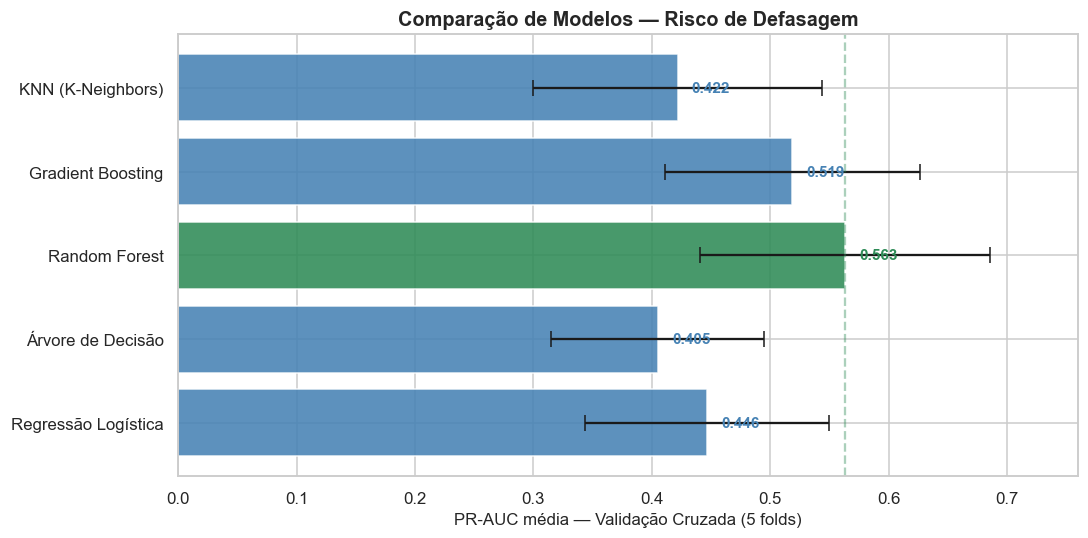

In [52]:
nomes = list(resultados.keys())
medias = [resultados[n]["media"] for n in nomes]
desvios = [resultados[n]["std"] for n in nomes]
melhor_idx = int(np.argmax(medias))

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["seagreen" if i == melhor_idx else "steelblue" for i in range(len(nomes))]
barras = ax.barh(nomes, medias, xerr=desvios, color=cores,
                 edgecolor="white", capsize=5, alpha=0.88)

for i, (barra, media) in enumerate(zip(barras, medias)):
    ax.text(media + 0.012, barra.get_y() + barra.get_height() / 2,
            f"{media:.3f}", va="center", fontsize=10,
            color="seagreen" if i == melhor_idx else "steelblue", fontweight="bold")

ax.axvline(x=max(medias), color="seagreen", linestyle="--", alpha=0.4)
ax.set_xlabel("PR-AUC média — Validação Cruzada (5 folds)", fontsize=11)
ax.set_title("Comparação de Modelos — Risco de Defasagem", fontsize=13)
ax.set_xlim(0, max(medias) * 1.35)

plt.tight_layout()
plt.show()

In [53]:
# seleciona automaticamente o melhor modelo pela maior PR-AUC média
nome_melhor = max(resultados, key=lambda n: resultados[n]["media"])
modelo_final = modelos[nome_melhor]

print(f"Melhor modelo: {nome_melhor}")
print(f"PR-AUC (validação cruzada): {resultados[nome_melhor]['media']:.4f} (± {resultados[nome_melhor]['std']:.4f})")

# treina no conjunto completo de treino
modelo_final.fit(X_train, y_train)

Melhor modelo: Random Forest
PR-AUC (validação cruzada): 0.5630 (± 0.1225)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

### Avaliação no Conjunto de Teste

O teste é feito utilizando os dados de 2023→2024, que o modelo nunca viu.

In [54]:
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
brier = brier_score_loss(y_test, y_proba)

print(f"  AUC       : {auc:.4f}")
print(f"  PR-AUC    : {pr_auc:.4f}   (aleatório = {y_test.mean():.4f})")
print(f"  Brier     : {brier:.4f}   (quanto menor, melhor calibrada a probabilidade)")
print()
print(classification_report(y_test, y_pred,
                            target_names=["Sem risco", "Em risco"], digits=3))

  AUC       : 0.8883
  PR-AUC    : 0.6165   (aleatório = 0.1490)
  Brier     : 0.0953   (quanto menor, melhor calibrada a probabilidade)

              precision    recall  f1-score   support

   Sem risco      0.926     0.902     0.914       651
    Em risco      0.511     0.588     0.547       114

    accuracy                          0.855       765
   macro avg      0.719     0.745     0.730       765
weighted avg      0.864     0.855     0.859       765



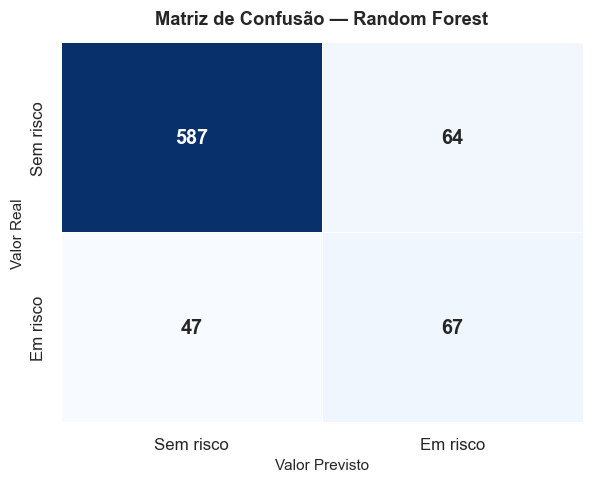

In [55]:
# Matriz de Confusão
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=0.5, cbar=False, ax=ax,
            xticklabels=["Sem risco", "Em risco"],
            yticklabels=["Sem risco", "Em risco"],
            annot_kws={"size": 13, "weight": "bold"})
ax.set_title(f"Matriz de Confusão — {nome_melhor}", pad=12)
ax.set_ylabel("Valor Real")
ax.set_xlabel("Valor Previsto")
plt.tight_layout()
plt.show()

### Importância das Variáveis

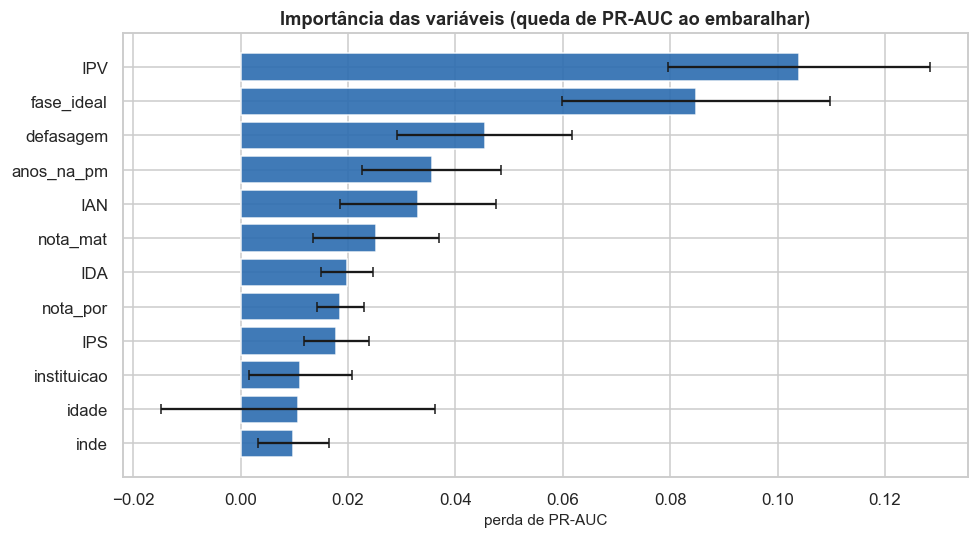

,variavel,importancia,desvio
0,IPV,0.104,0.024
1,fase_ideal,0.085,0.025
2,defasagem,0.045,0.016
3,anos_na_pm,0.036,0.013
4,IAN,0.033,0.015
5,nota_mat,0.025,0.012
6,IDA,0.020,0.005
7,nota_por,0.019,0.004
8,IPS,0.018,0.006
9,instituicao,0.011,0.010


In [56]:
perm = permutation_importance(
    modelo_final, X_test, y_test,
    scoring="average_precision", n_repeats=15, random_state=SEMENTE, n_jobs=-1,
)

importancia = pd.DataFrame({
    "variavel": X.columns,
    "importancia": perm.importances_mean,
    "desvio": perm.importances_std,
}).sort_values("importancia", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
principais = importancia.head(12).iloc[::-1]
ax.barh(principais["variavel"], principais["importancia"],
        xerr=principais["desvio"], color=COR["principal"], alpha=0.9, capsize=3)
ax.set_title("Importância das variáveis (queda de PR-AUC ao embaralhar)")
ax.set_xlabel("perda de PR-AUC")
plt.tight_layout()
plt.show()

display(importancia.head(10).round(4).reset_index(drop=True))

## Interpretação dos dados

 O modelo se apoia em três blocos:

1. **Comportamento:** IPV é a variável mais forte
2. **Estado Atual do Aluno:** fase_ideal e defasagem vêm logo atrás. Capturam o teto discutido lá atrás: o risco depende de quanto o aluno ainda tem a perder.
3. **Desempenho Acadêmico:** IAN, anos_na_pm, nota_mat e IDA formam um bloco de contribuições menores e parecidas entre si.

Autoavaliação e indicadores psicossociais quase não contribuem, coerente com as Perguntas 4 e 5, onde já se mostraram fracos.

### Calibração e escolha do ponto de corte

O `predict()` usa o corte padrão de 0,5, que não é o corte certo aqui. O que define o corte é a **capacidade de atendimento** da associação: quantos alunos a equipe consegue acompanhar de perto no próximo ciclo.

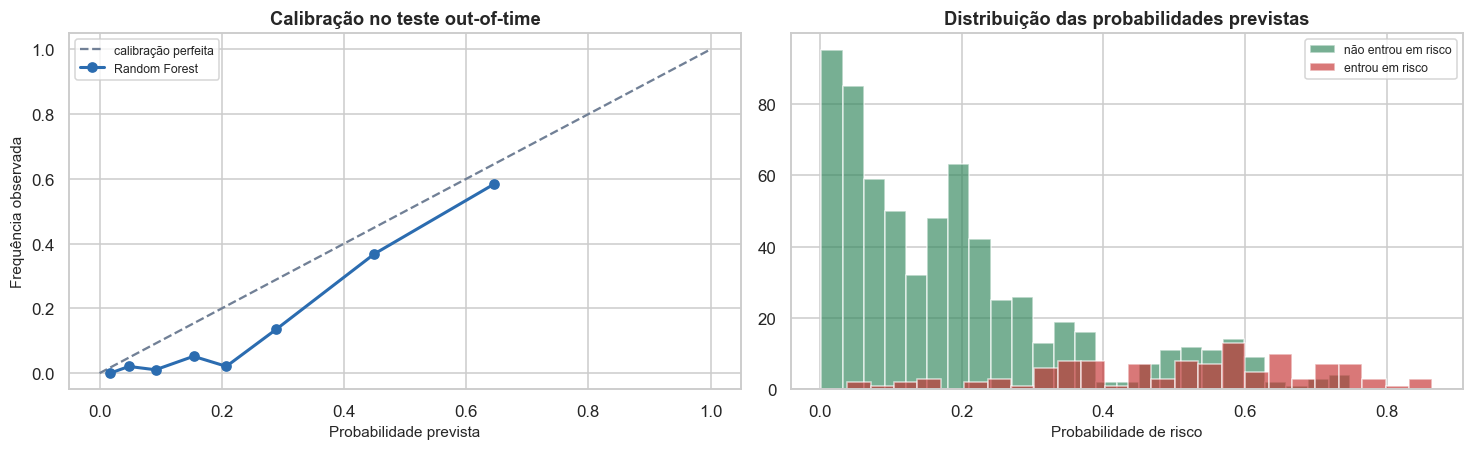

In [57]:
fig, eixos = plt.subplots(1, 2, figsize=(13.5, 4.2))

fracao, prevista = calibration_curve(y_test, y_proba, n_bins=8, strategy="quantile")
eixos[0].plot([0, 1], [0, 1], "--", color=COR["neutro"], label="calibração perfeita")
eixos[0].plot(prevista, fracao, "o-", color=COR["principal"], lw=2, label=nome_melhor)
eixos[0].set_title("Calibração no teste out-of-time")
eixos[0].set_xlabel("Probabilidade prevista")
eixos[0].set_ylabel("Frequência observada")
eixos[0].legend(fontsize=8)

eixos[1].hist(y_proba[y_test == 0], bins=25, alpha=0.65, color=COR["ok"],
              label="não entrou em risco")
eixos[1].hist(y_proba[y_test == 1], bins=25, alpha=0.65, color=COR["alerta"],
              label="entrou em risco")
eixos[1].set_title("Distribuição das probabilidades previstas")
eixos[1].set_xlabel("Probabilidade de risco")
eixos[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

,capacidade,alunos_priorizados,corte,precisao,revocacao,casos_capturados,ganho_sobre_aleatorio
0,top 5%,38,0.646,0.789,0.263,30,5.298
1,top 10%,76,0.577,0.632,0.421,48,4.238
2,top 15%,114,0.528,0.553,0.553,63,3.708
3,top 20%,153,0.422,0.503,0.675,77,3.377
4,top 25%,191,0.352,0.476,0.798,91,3.197
5,top 30%,229,0.298,0.441,0.886,101,2.960
6,top 40%,306,0.221,0.346,0.930,106,2.325


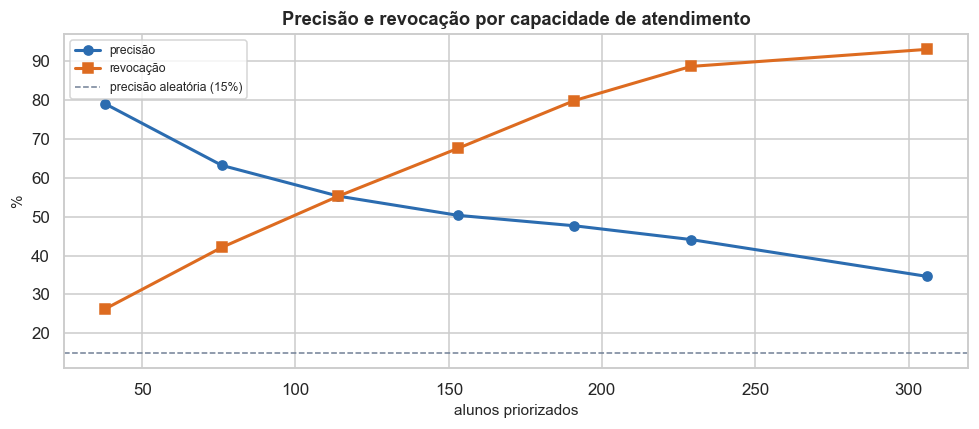

In [58]:
# quantos alunos a associação consegue acompanhar de perto?
ordenados = np.argsort(-y_proba)
y_teste_array = y_test.values

linhas = []
for capacidade in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    quantidade = int(len(y_proba) * capacidade)
    selecionados = ordenados[:quantidade]
    linhas.append({
        "capacidade": f"top {capacidade:.0%}",
        "alunos_priorizados": quantidade,
        "corte": y_proba[selecionados].min(),
        "precisao": y_teste_array[selecionados].mean(),
        "revocacao": y_teste_array[selecionados].sum() / y_teste_array.sum(),
        "casos_capturados": int(y_teste_array[selecionados].sum()),
        "ganho_sobre_aleatorio": y_teste_array[selecionados].mean() / y_teste_array.mean(),
    })

capacidade_df = pd.DataFrame(linhas)
display(capacidade_df.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(capacidade_df["alunos_priorizados"], capacidade_df["precisao"] * 100,
        "o-", color=COR["principal"], lw=2, label="precisão")
ax.plot(capacidade_df["alunos_priorizados"], capacidade_df["revocacao"] * 100,
        "s-", color=COR["atencao"], lw=2, label="revocação")
ax.axhline(y_test.mean() * 100, ls="--", color=COR["neutro"], lw=1,
           label=f"precisão aleatória ({y_test.mean():.0%})")
ax.set_title("Precisão e revocação por capacidade de atendimento")
ax.set_xlabel("alunos priorizados")
ax.set_ylabel("%")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Como ler.** Priorizando os **25% de maior risco** — 191 alunos —, o modelo captura **80% de todos os que de fato entrariam em defasagem**, com quase metade dos priorizados sendo casos reais.

Se a capacidade for menor, o top 10% entrega precisão de 63%: de cada 10 alunos chamados, 6 realmente estavam a caminho da defasagem.

O corte não é propriedade do modelo, é decisão de gestão. Por isso a entrega para o Streamlit é a probabilidade, com o corte configurável.

In [59]:
CORTE = float(capacidade_df.loc[capacidade_df["capacidade"] == "top 25%", "corte"].iloc[0])
y_pred_corte = (y_proba >= CORTE).astype(int)

print(f"Corte adotado: {CORTE:.3f} (contra o padrão de 0.5)\n")
print(classification_report(y_test, y_pred_corte,
                            target_names=["Sem risco", "Em risco"], digits=3))

Corte adotado: 0.352 (contra o padrão de 0.5)

              precision    recall  f1-score   support

   Sem risco      0.960     0.846     0.900       651
    Em risco      0.476     0.798     0.597       114

    accuracy                          0.839       765
   macro avg      0.718     0.822     0.748       765
weighted avg      0.888     0.839     0.854       765



### Matriz de priorização

O modelo responde "quem vai piorar". O IAN responde "quem já está mal". Cruzar os dois
resolve a limitação apontada no início desta parte e produz um instrumento que a equipe
usa direto.

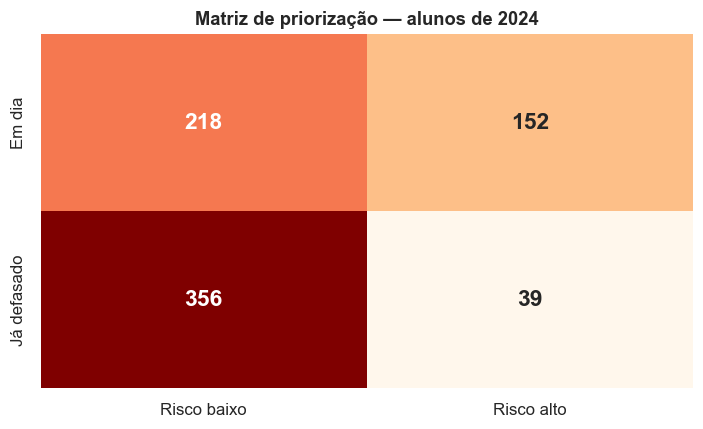

risco_alto,Risco baixo,Risco alto
ja_defasado,,
Em dia,218,152
Já defasado,356,39


In [60]:
priorizacao = transicoes[eh_teste].copy()
priorizacao["probabilidade"] = y_proba
priorizacao["risco_alto"] = priorizacao["probabilidade"] >= CORTE
priorizacao["ja_defasado"] = priorizacao["defasagem"] < 0

quadrantes = pd.crosstab(
    priorizacao["ja_defasado"].map({True: "Já defasado", False: "Em dia"}),
    priorizacao["risco_alto"].map({True: "Risco alto", False: "Risco baixo"}),
).reindex(index=["Em dia", "Já defasado"], columns=["Risco baixo", "Risco alto"])

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(quadrantes, annot=True, fmt="d", cmap="OrRd", cbar=False, ax=ax,
            annot_kws={"size": 15, "weight": "bold"})
ax.set_title("Matriz de priorização — alunos de 2024")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

display(quadrantes)

## Salvar o modelo

In [61]:
import joblib

PASTA_MODELOS = PASTA_BASE.parent / "modelos"
PASTA_MODELOS.mkdir(exist_ok=True)

# O artefato guarda tudo que o app precisa para reproduzir exatamente este
# modelo, sem ter que treinar de novo nem repetir o ETL:
#   - o Pipeline já treinado (imputer + scaler + Random Forest)
#   - os encoders, para converter as categorias do mesmo jeito
#   - a lista e a ordem das colunas esperadas na entrada
#   - o corte de decisão e as métricas registradas na validação
#   - o painel consolidado, que alimenta os gráficos do app
artefato = {
    "modelo": modelo_final,
    "nome_modelo": nome_melhor,
    "encoders": encoders,
    "variaveis_numericas": VARIAVEIS_NUMERICAS,
    "variaveis_categoricas": VARIAVEIS_CATEGORICAS,
    "ordem_colunas": list(X.columns),
    "corte_sugerido": CORTE,
    "treinado_em": "transições 2022 → 2023",
    "validado_em": "transições 2023 → 2024",
    "metricas_teste": {
        "auc": float(auc),
        "pr_auc": float(pr_auc),
        "brier": float(brier),
        "prevalencia": float(y_test.mean()),
    },
    "definicao_alvo": "entrar em defasagem ou aprofundar a defasagem existente no ano seguinte",
    "painel": painel,
    "transicoes": transicoes,
}

caminho_modelo = PASTA_MODELOS / "modelo_risco_defasagem.joblib"
# compress=3 reduz o arquivo de ~4 MB para ~1 MB sem custo perceptível de leitura
joblib.dump(artefato, caminho_modelo, compress=3)

print(f"Modelo salvo em: {caminho_modelo}")
print(f"Tamanho do arquivo: {caminho_modelo.stat().st_size / 1024:.0f} KB")
print(f"Chaves guardadas: {list(artefato.keys())}")

Modelo salvo em: c:\Users\USUARIO\Documents\GitHub\datathon_2026\modelos\modelo_risco_defasagem.joblib
Tamanho do arquivo: 1119 KB
Chaves guardadas: ['modelo', 'nome_modelo', 'encoders', 'variaveis_numericas', 'variaveis_categoricas', 'ordem_colunas', 'corte_sugerido', 'treinado_em', 'validado_em', 'metricas_teste', 'definicao_alvo', 'painel', 'transicoes']


---
# Parte 5 — Conclusões

## O que os dados dizem

**O programa melhora os indicadores agregados — mas a melhora é composicional.** O INDE
médio subiu de 7,04 (2022) para 7,40 (2024) e a defasagem caiu de 70% para 46% dos alunos.
Entre os 434 alunos acompanhados nos três anos, porém, a variação média do INDE é zero. Os
alunos com pior desempenho são justamente os que não retornam (INDE 6,51 contra 7,26 dos
que ficam), e os ingressantes chegam acima da média dos veteranos. **Retenção é o tema que
os dados apontam com mais força.**

**Onde o programa comprovadamente entrega é na adequação de nível.** A defasagem cai de
forma consistente com o tempo de casa — de 60% no primeiro ano para 29% no oitavo — mesmo
sem elevação do INDE. Recolocar o aluno na fase certa é o resultado mais sólido da série.

**Engajamento é a alavanca.** O IEG é o indicador que mais se conecta com aprendizagem
(r = 0,54) e ponto de virada (r = 0,54), e é o único claramente acionável pela equipe.
Aprendizagem e ponto de virada são consequências; engajamento é causa.

**A autoavaliação não acompanha a realidade.** Correlação de 0,10 a 0,22 com o desempenho
real. 30% dos registros são de alunos que se superestimam em mais de 3 pontos, com o pior
IDA da base — não pedem ajuda e por isso não aparecem nos encaminhamentos.

**IPS e IPP medem outra coisa.** Nenhum dos dois antecipa queda de desempenho nem confirma
a defasagem do IAN. Não é defeito conceitual: são dimensões distintas. Mas ambos têm
problemas de medição — o IPP quase não varia entre alunos e o IPS teve uma oscilação
inexplicada em 2023.

## O modelo

Random Forest, escolhido automaticamente por PR-AUC na validação cruzada, treinado nas
transições 2022→2023 e validado out-of-time em 2023→2024: **AUC 0,89 e PR-AUC 0,62** contra
uma prevalência de 0,15. Priorizando os 25% de maior risco — 191 alunos —, captura **80%
dos que de fato entram em defasagem**, com precisão de 48%: mais de três vezes melhor que
escolher ao acaso.

O modelo é um **alerta precoce, não um ranking de gravidade**. Deve ser lido junto com o
IAN, na matriz de priorização do fim da Parte 4.

## Recomendações para a Passos Mágicos

1. **Investigar a evasão seletiva.** É o achado de maior impacto: os alunos que saem são
   os de pior desempenho. Entender por que saem vale mais, hoje, do que qualquer ajuste
   pedagógico.
2. **Rodar o modelo no fim de cada ciclo** e usar a matriz de priorização para montar a
   lista de acompanhamento do ano seguinte.
3. **Busca ativa no grupo "engajado mas travado"** — 22% da base, adesão garantida, falta
   método.
4. **Busca ativa no grupo que se superestima** — 30% dos registros, pior desempenho da
   base, e que por definição não vai pedir ajuda.
5. **Corrigir a governança dos dados**: o dicionário está desatualizado nas faixas de
   Pedra, `Atingiu PV` e `Rec Psicologia` deixaram de ser preenchidos em 2023/2024, o
   `Ano ingresso` foi reescrito na base de 2024 e o IPS de 2023 precisa de conferência.

## Limitações honestas

- O treino tem 600 pares e 98 casos positivos. É pouco, e as métricas têm incerteza real —
  o desvio padrão da AUC na validação cruzada chega a 0,08.
- Sem `IPP` no modelo, porque a coluna não existe em 2022.
- O modelo prevê **piora**, não gravidade. Alunos já severamente defasados recebem
  probabilidade baixa por efeito de teto, e por isso o resultado só deve ser lido junto
  com o IAN.
- A nota de inglês só existe para um terço dos alunos.
- Sem `Atingiu PV` em 2023/2024, não foi possível modelar o Ponto de Virada diretamente.

## Próximos passos

- Aplicação Streamlit consumindo `modelos/modelo_risco_defasagem.joblib`.
- Apresentação gerencial com o storytelling desta análise.
- Vídeo de até 5 minutos.
